#  DATA Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv(r"C:\Users\kirti\OneDrive\Documents\College Poject\eighthr.data", header=None)
df.to_csv("output.csv", index=False)

As we have loaded the data, we saw that there were no column names, also the missing values are marked as '?' which needs to be cleaned and handled.

In [4]:
df.columns = ["Date","WSR0","WSR1","WSR2","WSR3","WSR4","WSR5","WSR6","WSR7","WSR8","WSR9","WSR10","WSR11","WSR12","WSR13","WSR14","WSR15","WSR16","WSR17","WSR18","WSR19","WSR20","WSR21","WSR22","WSR23","WSR_PK","WSR_AV","T0","T1","T2","T3","T4","T5","T6","T7","T8","T9","T10","T11","T12","T13","T14","T15","T16","T17","T18","T19","T20","T21","T22","T23","T_PK","T_AV","T85","RH85","U85","V85","HT85","T70","RH70","U70","V70","HT70","T50","RH50","U50","V50","HT50","KI","TT","SLP","SLP_","Precp","Target"]
df

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
0,1/1/1998,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0.0
1,1/2/1998,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0.0
2,1/3/1998,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0.0
3,1/4/1998,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0.0
4,1/5/1998,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,...,?,?,?,?,?,?,?,?,0.58,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529,12/27/2004,0.3,0.4,0.5,0.5,0.2,0.3,0.4,0.4,1.3,...,0.07,7.93,-4.41,5800,-25.6,21.8,10295,65,0,0.0
2530,12/28/2004,1,1.4,1.1,1.7,1.5,1.7,1.8,1.5,2.1,...,0.04,5.95,-1.14,5845,-19.4,19.1,10310,15,0,0.0
2531,12/29/2004,0.8,0.8,1.2,0.9,0.4,0.6,0.8,1.1,1.5,...,0.06,7.8,-0.64,5845,-9.6,35.2,10275,-35,0,0.0
2532,12/30/2004,1.3,0.9,1.5,1.2,1.6,1.8,1.1,1,1.9,...,0.25,7.72,-0.89,5845,-19.6,34.2,10245,-30,0.05,0.0


We have used the attribute information given in another folder named as eighthr.names with the dataset folder(eighr.data) to load column names as shown above.

In [5]:
df.shape

(2534, 74)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2534 entries, 0 to 2533
Data columns (total 74 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2534 non-null   object 
 1   WSR0    2534 non-null   object 
 2   WSR1    2534 non-null   object 
 3   WSR2    2534 non-null   object 
 4   WSR3    2534 non-null   object 
 5   WSR4    2534 non-null   object 
 6   WSR5    2534 non-null   object 
 7   WSR6    2534 non-null   object 
 8   WSR7    2534 non-null   object 
 9   WSR8    2534 non-null   object 
 10  WSR9    2534 non-null   object 
 11  WSR10   2534 non-null   object 
 12  WSR11   2534 non-null   object 
 13  WSR12   2534 non-null   object 
 14  WSR13   2534 non-null   object 
 15  WSR14   2534 non-null   object 
 16  WSR15   2534 non-null   object 
 17  WSR16   2534 non-null   object 
 18  WSR17   2534 non-null   object 
 19  WSR18   2534 non-null   object 
 20  WSR19   2534 non-null   object 
 21  WSR20   2534 non-null   object 
 22  

All the columns are of object type according to the data reader, but actually our dataset has only 3 types of values which are date int and float .


### Lets process the dataset and make it cleaner for the further process.

First lets sort out Target variable and check what are the values that it takes.

In [7]:
df.groupby('Target').count()

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,T50,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp
Target,,,,,,,,,,,,,,,,,,,,,
0.0,2374,2374,2374,2374,2374,2374,2374,2374,2374,2374,...,2374,2374,2374,2374,2374,2374,2374,2374,2374,2374
1.0,160,160,160,160,160,160,160,160,160,160,...,160,160,160,160,160,160,160,160,160,160


In [8]:
df.Target = pd.Categorical(df.Target,[0.0,1.0])
#This line converts the Target column into categorical type with two defined classes (0 and 1), which is useful for classification modeling and label encoding.

Machine learning models usually need numbers, not text labels, so converting a categorical column into numeric codes.

In [9]:
df.Target = df.Target.cat.codes   #This line converts categorical labels in the Target column into numeric integer codes for machine learning model training.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2534 entries, 0 to 2533
Data columns (total 74 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    2534 non-null   object
 1   WSR0    2534 non-null   object
 2   WSR1    2534 non-null   object
 3   WSR2    2534 non-null   object
 4   WSR3    2534 non-null   object
 5   WSR4    2534 non-null   object
 6   WSR5    2534 non-null   object
 7   WSR6    2534 non-null   object
 8   WSR7    2534 non-null   object
 9   WSR8    2534 non-null   object
 10  WSR9    2534 non-null   object
 11  WSR10   2534 non-null   object
 12  WSR11   2534 non-null   object
 13  WSR12   2534 non-null   object
 14  WSR13   2534 non-null   object
 15  WSR14   2534 non-null   object
 16  WSR15   2534 non-null   object
 17  WSR16   2534 non-null   object
 18  WSR17   2534 non-null   object
 19  WSR18   2534 non-null   object
 20  WSR19   2534 non-null   object
 21  WSR20   2534 non-null   object
 22  WSR21   2534 non-null   

In [11]:
df  #now we see that the Target column has integer values 0/1.

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
0,1/1/1998,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0
1,1/2/1998,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0
2,1/3/1998,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0
3,1/4/1998,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0
4,1/5/1998,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,...,?,?,?,?,?,?,?,?,0.58,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529,12/27/2004,0.3,0.4,0.5,0.5,0.2,0.3,0.4,0.4,1.3,...,0.07,7.93,-4.41,5800,-25.6,21.8,10295,65,0,0
2530,12/28/2004,1,1.4,1.1,1.7,1.5,1.7,1.8,1.5,2.1,...,0.04,5.95,-1.14,5845,-19.4,19.1,10310,15,0,0
2531,12/29/2004,0.8,0.8,1.2,0.9,0.4,0.6,0.8,1.1,1.5,...,0.06,7.8,-0.64,5845,-9.6,35.2,10275,-35,0,0
2532,12/30/2004,1.3,0.9,1.5,1.2,1.6,1.8,1.1,1,1.9,...,0.25,7.72,-0.89,5845,-19.6,34.2,10245,-30,0.05,0


In [12]:
df.replace('?', np.nan, inplace = True)  #replacing ? with NaN/Missing value as machine learning and pandas work better when missing values are stored as NaN.
df

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
0,1/1/1998,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0
1,1/2/1998,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0
2,1/3/1998,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0
3,1/4/1998,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0
4,1/5/1998,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.58,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529,12/27/2004,0.3,0.4,0.5,0.5,0.2,0.3,0.4,0.4,1.3,...,0.07,7.93,-4.41,5800,-25.6,21.8,10295,65,0,0
2530,12/28/2004,1,1.4,1.1,1.7,1.5,1.7,1.8,1.5,2.1,...,0.04,5.95,-1.14,5845,-19.4,19.1,10310,15,0,0
2531,12/29/2004,0.8,0.8,1.2,0.9,0.4,0.6,0.8,1.1,1.5,...,0.06,7.8,-0.64,5845,-9.6,35.2,10275,-35,0,0
2532,12/30/2004,1.3,0.9,1.5,1.2,1.6,1.8,1.1,1,1.9,...,0.25,7.72,-0.89,5845,-19.6,34.2,10245,-30,0.05,0


In [13]:
df.iloc[0:,1:73] = df.iloc[0:,1:73].astype(float)  ##converting all columns except date and Target to float for further processing.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2534 entries, 0 to 2533
Data columns (total 74 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    2534 non-null   object
 1   WSR0    2235 non-null   object
 2   WSR1    2242 non-null   object
 3   WSR2    2240 non-null   object
 4   WSR3    2242 non-null   object
 5   WSR4    2241 non-null   object
 6   WSR5    2242 non-null   object
 7   WSR6    2243 non-null   object
 8   WSR7    2245 non-null   object
 9   WSR8    2244 non-null   object
 10  WSR9    2247 non-null   object
 11  WSR10   2246 non-null   object
 12  WSR11   2242 non-null   object
 13  WSR12   2247 non-null   object
 14  WSR13   2246 non-null   object
 15  WSR14   2246 non-null   object
 16  WSR15   2248 non-null   object
 17  WSR16   2250 non-null   object
 18  WSR17   2251 non-null   object
 19  WSR18   2248 non-null   object
 20  WSR19   2242 non-null   object
 21  WSR20   2240 non-null   object
 22  WSR21   2241 non-null   

* We made the Target variable categorical as it has only 2 values which is 1 and 0 for ozone day and normal day respectively. 
* We changed all the '?' which were the missing values to NaN for better handling.
* We also changed all the object type to float type as they should be for processing and to use mathematic expressions on them.

# data types (Only numeric and categorical)
We have all the attributes as numeric datatypes except for Target which is numeric too but has categorical function. 

In [14]:
ozone = (df['Target'] == 1)
df[ozone]

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
94,4/5/1998,0.4,0.5,2.1,2.2,2.5,2.4,2.1,2.9,3.6,...,0.1,20.91,-3.9,5755.0,-15.9,19.4,10140.0,20.0,0.0,1
100,4/11/1998,0.0,0.6,0.4,0.3,0.1,0.3,0.2,1.4,2.6,...,0.15,17.27,-12.27,5795.0,-12.6,24.2,10220.0,45.0,0.0,1
109,4/20/1998,1.8,0.3,0.1,0.1,0.1,0.2,0.2,0.7,0.9,...,0.31,20.36,2.61,5740.0,-3.5,30.6,10180.0,35.0,0.0,1
112,4/23/1998,0.5,0.1,0.1,0.1,0.1,0.2,0.3,0.8,1.2,...,0.14,16.78,-17.99,5680.0,-2.4,37.6,10195.0,-10.0,0.0,1
114,4/25/1998,3.1,2.4,2.4,3.0,3.4,3.4,3.9,4.5,5.5,...,0.13,9.22,-5.96,5790.0,7.1,35.4,10165.0,-25.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2413,9/2/2004,0.4,0.8,0.8,0.8,0.8,1.2,1.2,1.5,1.9,...,0.44,4.42,2.42,5880.0,8.9,42.4,10155.0,-25.0,1.19,1
2428,9/17/2004,0.3,0.4,0.5,0.4,0.1,0.5,0.9,1.3,2.0,...,0.13,3.22,-3.49,5885.0,36.45,48.0,10100.0,40.0,0.0,1
2429,9/18/2004,0.2,0.0,0.2,0.2,0.4,0.3,0.1,0.4,0.6,...,0.09,0.87,-2.91,5910.0,33.85,48.05,10130.0,30.0,0.0,1
2440,9/29/2004,0.1,0.3,1.0,0.5,0.4,0.4,0.5,1.0,1.1,...,0.07,14.12,6.61,5835.0,20.2,36.4,10150.0,25.0,0.0,1


Through this we understand that only 160 rows of 2534 rows have the Target value as 1 which is ozone day. 
* This just shows that the data set is biased.

In [15]:
df=df.set_index('Date') #This line sets the Date column as the dataframe index so the dataset can be treated as time series data for filtering, plotting, and forecasting.

In [16]:
df.corr() #this is used to find out the correlation between numerical columns annd provides a correlation matrix.

,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,WSR9,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
WSR0,1.000000,0.919949,0.859995,0.803327,0.754117,0.703228,0.666457,0.597571,0.543161,0.501200,...,0.134977,0.238931,0.358054,-0.161063,0.105988,0.163312,-0.126468,-0.126014,0.104506,-0.179239
WSR1,0.919949,1.000000,0.924980,0.851661,0.802565,0.746868,0.709706,0.641584,0.576523,0.527630,...,0.124136,0.249317,0.360036,-0.181466,0.102570,0.155650,-0.114295,-0.114501,0.116779,-0.179387
WSR2,0.859995,0.924980,1.000000,0.917333,0.847342,0.785949,0.747312,0.674414,0.607946,0.561148,...,0.111198,0.283342,0.374636,-0.204909,0.089480,0.140450,-0.094796,-0.127386,0.110784,-0.183836
WSR3,0.803327,0.851661,0.917333,1.000000,0.913697,0.845998,0.789078,0.708362,0.626228,0.575307,...,0.110482,0.296899,0.368576,-0.226872,0.082334,0.134383,-0.094552,-0.119596,0.117405,-0.176285
WSR4,0.754117,0.802565,0.847342,0.913697,1.000000,0.914480,0.836091,0.735612,0.629501,0.568939,...,0.112085,0.289031,0.357755,-0.235024,0.078604,0.122118,-0.075441,-0.110479,0.141422,-0.165449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TT,0.163312,0.155650,0.140450,0.134383,0.122118,0.110794,0.122514,0.154999,0.091434,-0.019867,...,0.363812,-0.247394,0.231559,0.249951,0.857312,1.000000,-0.532956,-0.281695,0.148189,0.039728
SLP,-0.126468,-0.114295,-0.094796,-0.094552,-0.075441,-0.078592,-0.094972,-0.154033,-0.134713,-0.057710,...,-0.150666,0.140259,-0.257582,-0.075359,-0.485845,-0.532956,1.000000,0.334727,-0.097182,-0.098474
SLP_,-0.126014,-0.114501,-0.127386,-0.119596,-0.110479,-0.103816,-0.103946,-0.109994,-0.067385,-0.055893,...,-0.123505,0.082457,-0.191174,-0.024264,-0.239051,-0.281695,0.334727,1.000000,-0.087558,-0.007498
Precp,0.104506,0.116779,0.110784,0.117405,0.141422,0.133175,0.124507,0.084155,0.022544,-0.042140,...,0.213446,0.006703,0.210103,0.020327,0.199733,0.148189,-0.097182,-0.087558,1.000000,-0.062781


Correlation helps to find out what features(which columns out of all 73 columns) strongly affects the Target.
Heatmap is a colorful visual representation of correlation matrix.Instead of reading many numbers, heatmap shows relationships quickly.

<Axes: >

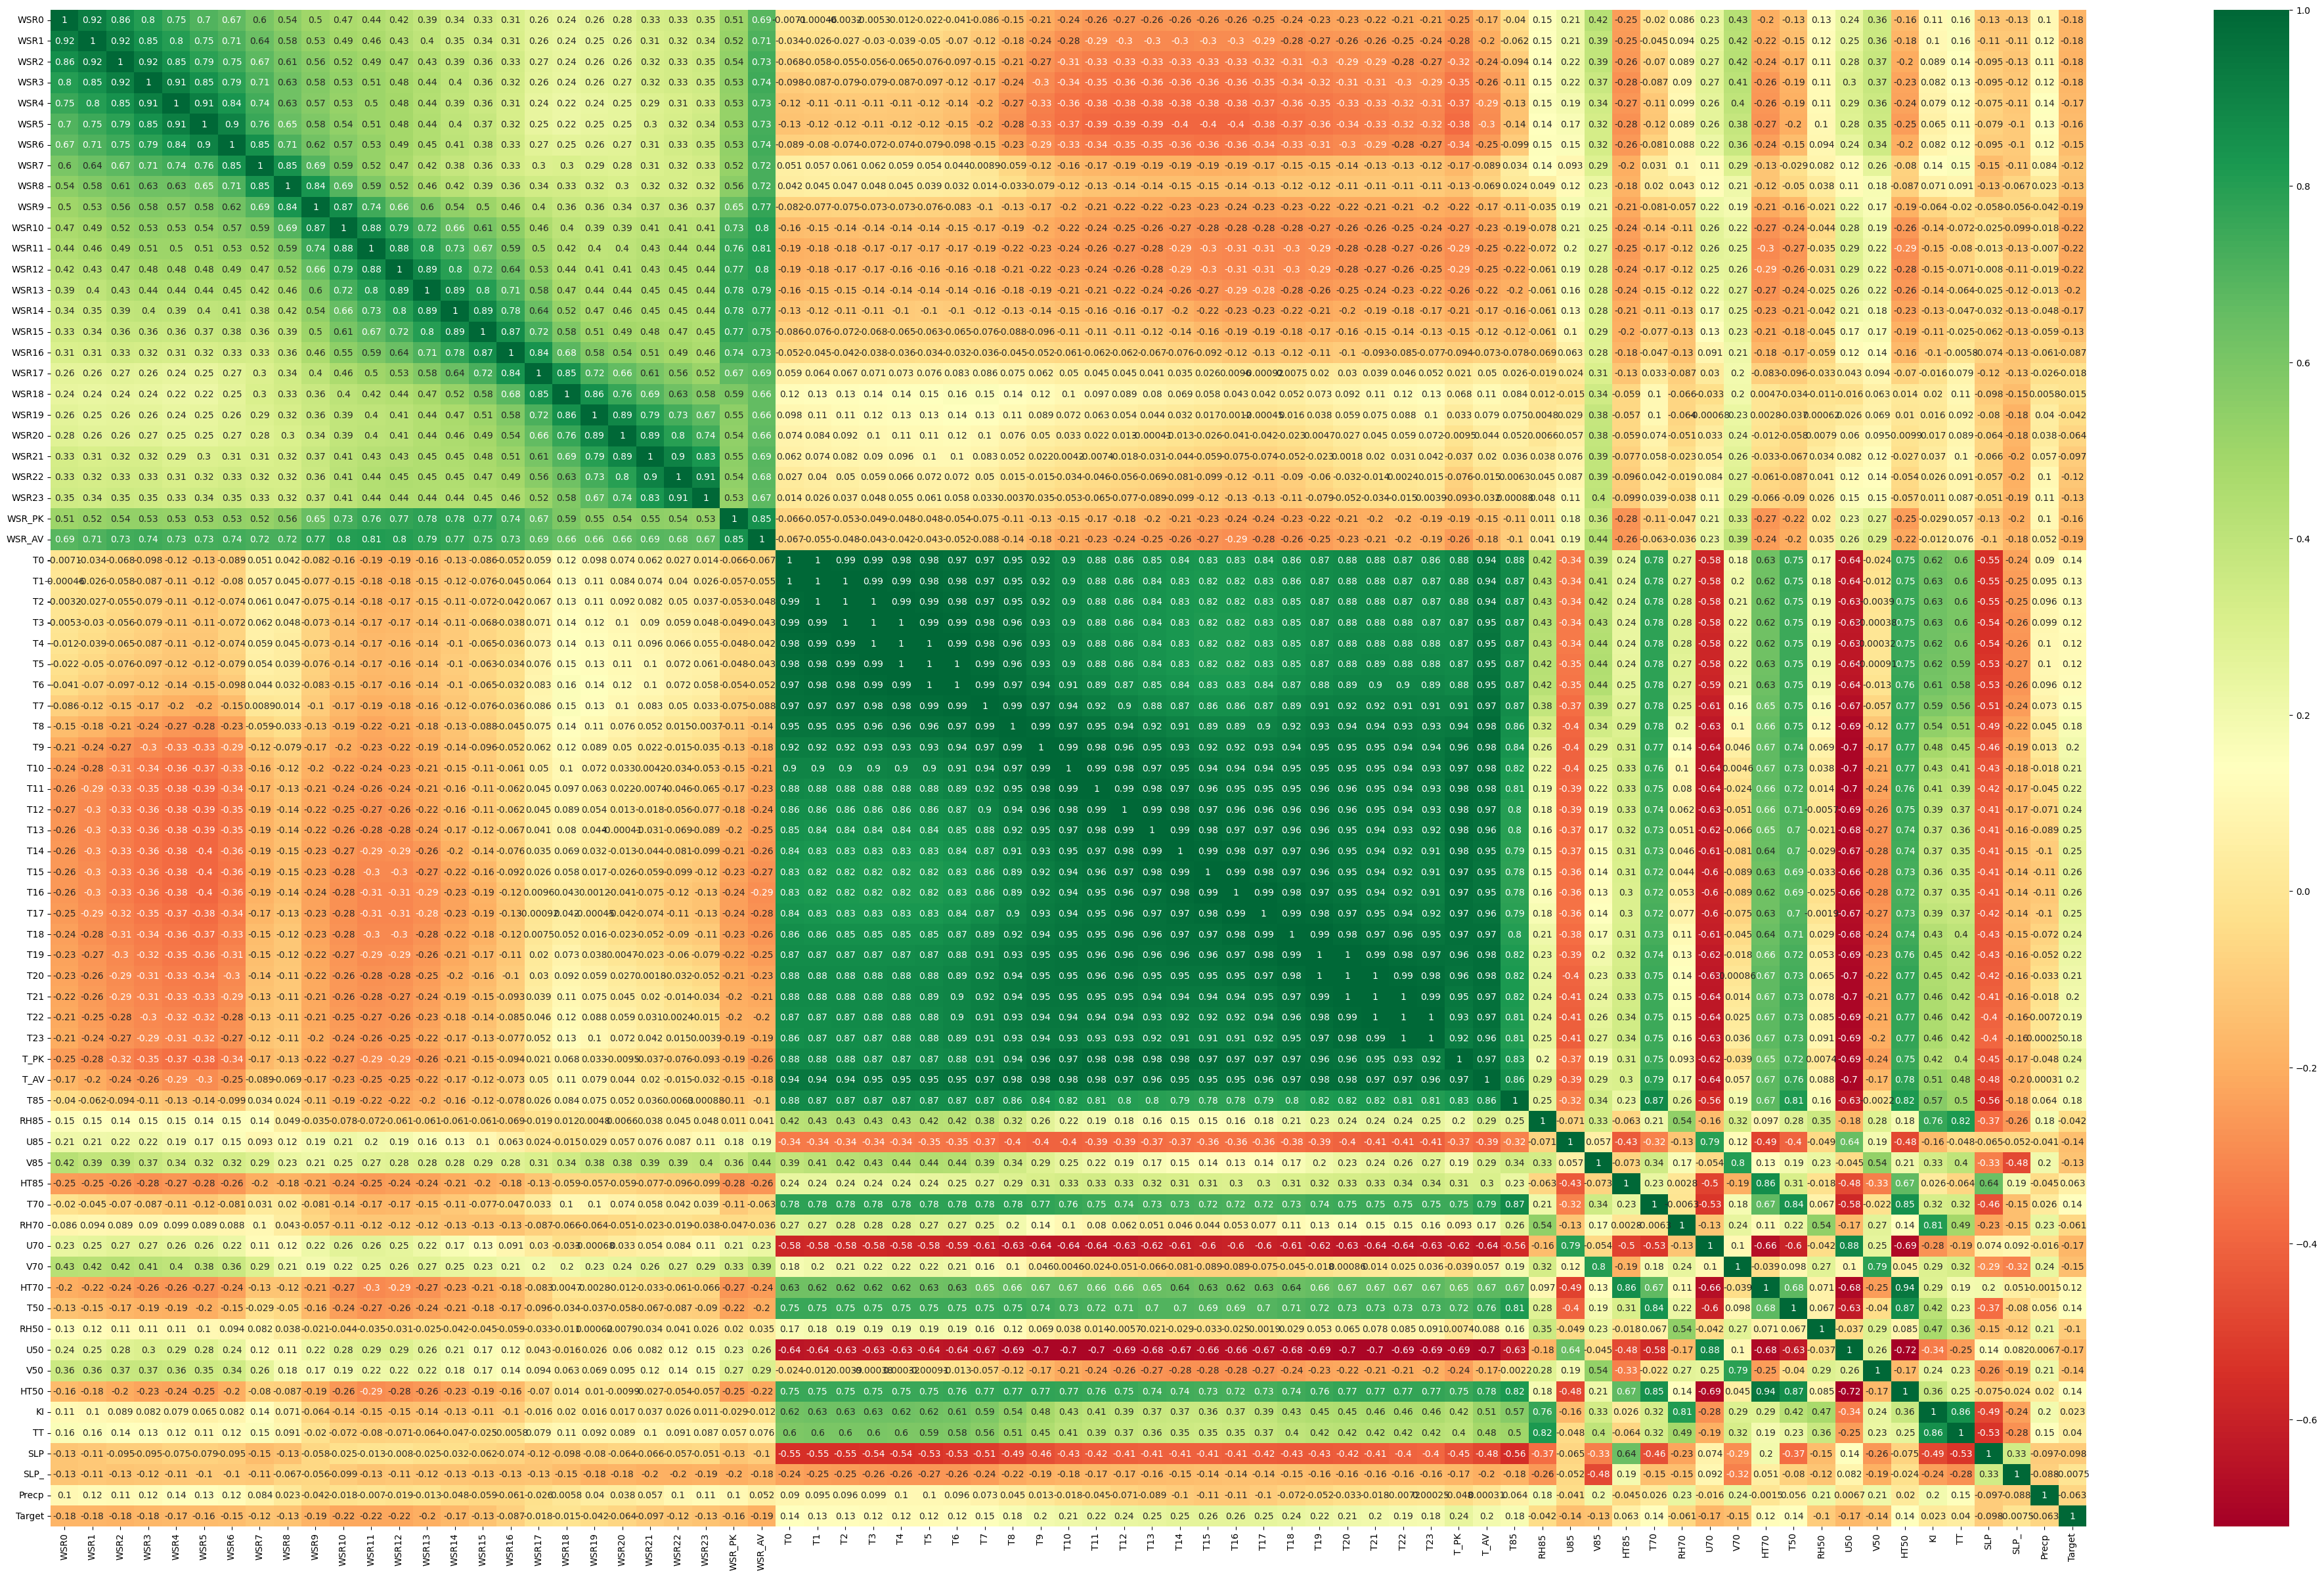

In [17]:
plt.figure(figsize=(50,30))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')

We already have 73 attributes out of which 48 attributes are just the hourly readings of certain attributes and we can ignore them as they have high correlation with some other attributes, just so that later on they dont produce errors or irregularity in predictions.

* WSR_0 to WSR_23 is the wind speed from 0 to 24 hours and certainly can be replaced by WSR_AV and WSR_PK which is average and peek of the same.
* T_0 to T_23 is the temperature from 0 to 24 hours and certainly can be replaced by T_AV and T_PK which is average and peek of the same.

# Which independent variables have missing data? How much?

Dropping those which are not necessary and calculating the missing data.

In [18]:
#Dropping the columns which are not necessary and might cause problems later 

df.drop(['WSR0','WSR1','WSR2', 'WSR3','WSR4', 'WSR5','WSR6', 'WSR7','WSR8', 'WSR9','WSR10', 'WSR11','WSR12', 'WSR13',
         'WSR14', 'WSR15','WSR16', 'WSR17','WSR18', 'WSR19','WSR20', 'WSR21','WSR22', 'WSR23',
         'T0','T1','T2', 'T3','T4', 'T5','T6', 'T7','T8', 'T9','T10', 'T11','T12', 'T13',
         'T14', 'T15','T16', 'T17','T18', 'T19','T20', 'T21','T22', 'T23'], axis = 1, inplace=True)


df.iloc[0:,0:].isnull().sum() #provides a sum of null values in each column

WSR_PK    273
WSR_AV    273
T_PK      175
T_AV      175
T85        99
RH85      105
U85       180
V85       180
HT85       95
T70       107
RH70      115
U70       157
V70       157
HT70      100
T50       115
RH50      125
U50       210
V50       210
HT50      112
KI        136
TT        125
SLP        95
SLP_      158
Precp       2
Target      0
dtype: int64

In [19]:
#Checking the percentage of the missing values

missing_list = df.columns[df.isna().any()].tolist()  ##forms a list of columns that has null/NaN  values
missing_count = []      
for i in missing_list:
  missing_count.append(sum(pd.isnull(df[str(i)])))  #This line counts the number of missing (null/NaN) values in a specific column and adds that count to a list called missing_count.

d = {'Missing_Column':missing_list,'Missing_Values':missing_count}
Missing_DF = pd.DataFrame(d)
Missing_DF["%_Missing"] = (Missing_DF['Missing_Values']/df.shape[0])*100
Missing_DF

,Missing_Column,Missing_Values,%_Missing
0,WSR_PK,273,10.773481
1,WSR_AV,273,10.773481
2,T_PK,175,6.906077
3,T_AV,175,6.906077
4,T85,99,3.906867
5,RH85,105,4.143646
6,U85,180,7.103394
7,V85,180,7.103394
8,HT85,95,3.749013
9,T70,107,4.222573


We saw that all the independant variables have some missing data and the max percentage is 10% so we can drop the rows having such NaN values for now.

In [20]:
#Copying all the data into another so that we can use the dataframe with NaN values later on
df_nan = df.copy(deep=True)
df_nan

,WSR_PK,WSR_AV,T_PK,T_AV,T85,RH85,U85,V85,HT85,T70,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
Date,,,,,,,,,,,,,,,,,,,,,
1/1/1998,5.5,3.1,19.1,12.5,6.7,0.11,3.83,0.14,1612.0,-2.3,...,0.15,10.67,-1.56,5795.0,-12.1,17.9,10330.0,-55.0,0.0,0
1/2/1998,5.5,3.4,22.4,17.8,9.0,0.25,-0.41,9.53,1594.5,-2.2,...,0.48,8.39,3.84,5805.0,14.05,29.0,10275.0,-55.0,0.0,0
1/3/1998,5.6,3.5,22.2,18.7,9.0,0.56,0.89,10.17,1568.5,0.9,...,0.6,6.94,9.8,5790.0,17.9,41.3,10235.0,-40.0,0.0,0
1/4/1998,4.7,3.2,19.6,18.7,9.9,0.89,-0.34,8.58,1546.5,3.0,...,0.49,8.73,10.54,5775.0,31.15,51.7,10195.0,-40.0,2.08,0
1/5/1998,3.7,2.3,26.0,21.1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.58,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/27/2004,3.9,1.6,14.8,7.7,5.5,0.33,-2.25,-1.92,1576.0,3.2,...,0.07,7.93,-4.41,5800.0,-25.6,21.8,10295.0,65.0,0.0,0
12/28/2004,5.0,2.6,18.4,12.9,5.8,0.27,-2.45,4.71,1600.5,3.4,...,0.04,5.95,-1.14,5845.0,-19.4,19.1,10310.0,15.0,0.0,0
12/29/2004,3.9,1.9,20.6,17.7,7.5,0.79,7.57,3.13,1591.0,4.6,...,0.06,7.8,-0.64,5845.0,-9.6,35.2,10275.0,-35.0,0.0,0


In [21]:
#Dropping all the NaN rows
df_nan=df_nan.dropna()
df_nan

,WSR_PK,WSR_AV,T_PK,T_AV,T85,RH85,U85,V85,HT85,T70,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
Date,,,,,,,,,,,,,,,,,,,,,
1/1/1998,5.5,3.1,19.1,12.5,6.7,0.11,3.83,0.14,1612.0,-2.3,...,0.15,10.67,-1.56,5795.0,-12.1,17.9,10330.0,-55.0,0.0,0
1/2/1998,5.5,3.4,22.4,17.8,9.0,0.25,-0.41,9.53,1594.5,-2.2,...,0.48,8.39,3.84,5805.0,14.05,29.0,10275.0,-55.0,0.0,0
1/3/1998,5.6,3.5,22.2,18.7,9.0,0.56,0.89,10.17,1568.5,0.9,...,0.6,6.94,9.8,5790.0,17.9,41.3,10235.0,-40.0,0.0,0
1/4/1998,4.7,3.2,19.6,18.7,9.9,0.89,-0.34,8.58,1546.5,3.0,...,0.49,8.73,10.54,5775.0,31.15,51.7,10195.0,-40.0,2.08,0
1/7/1998,7.0,5.2,15.8,9.7,12.6,0.98,0.48,7.46,1413.0,4.6,...,0.84,6.86,25.6,5695.0,26.75,48.45,10040.0,-80.0,0.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/27/2004,3.9,1.6,14.8,7.7,5.5,0.33,-2.25,-1.92,1576.0,3.2,...,0.07,7.93,-4.41,5800.0,-25.6,21.8,10295.0,65.0,0.0,0
12/28/2004,5.0,2.6,18.4,12.9,5.8,0.27,-2.45,4.71,1600.5,3.4,...,0.04,5.95,-1.14,5845.0,-19.4,19.1,10310.0,15.0,0.0,0
12/29/2004,3.9,1.9,20.6,17.7,7.5,0.79,7.57,3.13,1591.0,4.6,...,0.06,7.8,-0.64,5845.0,-9.6,35.2,10275.0,-35.0,0.0,0


In [22]:
df_nan.shape

(1921, 25)

In [23]:
#Checking if we lost any significant amount of Target variables
ozone = (df_nan['Target'] == 1)
df_nan[ozone]

,WSR_PK,WSR_AV,T_PK,T_AV,T85,RH85,U85,V85,HT85,T70,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
Date,,,,,,,,,,,,,,,,,,,,,
4/5/1998,3.6,2.2,22.2,16.2,11.4,0.13,2.84,-5.45,1482.5,6.1,...,0.1,20.91,-3.9,5755.0,-15.9,19.4,10140.0,20.0,0.0,1
4/11/1998,4.9,2.6,24.6,18.3,10.3,0.28,2.55,-8.85,1561.0,1.15,...,0.15,17.27,-12.27,5795.0,-12.6,24.2,10220.0,45.0,0.0,1
4/20/1998,3.1,1.6,24.2,18.2,7.0,0.53,-2.29,-5.44,1520.5,0.05,...,0.31,20.36,2.61,5740.0,-3.5,30.6,10180.0,35.0,0.0,1
4/23/1998,3.4,1.5,26.3,18.9,6.3,0.43,3.18,-6.76,1535.0,-4.1,...,0.14,16.78,-17.99,5680.0,-2.4,37.6,10195.0,-10.0,0.0,1
4/25/1998,5.5,4.2,25.1,21.4,11.6,0.58,1.72,5.03,1520.0,5.3,...,0.13,9.22,-5.96,5790.0,7.1,35.4,10165.0,-25.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7/16/2004,3.4,1.6,33.6,29.4,19.2,0.85,-0.67,-0.74,1543.5,11.1,...,0.1,-1.07,-5.03,5900.0,27.35,47.95,10125.0,0.0,0.0,1
8/11/2004,3.0,1.5,33.3,28.5,17.3,0.72,2.87,-3.13,1539.0,9.9,...,0.16,5.61,-0.67,5885.0,22.35,40.15,10130.0,-15.0,0.03,1
9/2/2004,2.1,1.2,29.2,25.3,16.0,0.75,-2.48,-0.38,1553.0,8.9,...,0.44,4.42,2.42,5880.0,8.9,42.4,10155.0,-25.0,1.19,1


In [24]:
df.columns

Index(['WSR_PK', 'WSR_AV', 'T_PK', 'T_AV', 'T85', 'RH85', 'U85', 'V85', 'HT85',
       'T70', 'RH70', 'U70', 'V70', 'HT70', 'T50', 'RH50', 'U50', 'V50',
       'HT50', 'KI', 'TT', 'SLP', 'SLP_', 'Precp', 'Target'],
      dtype='object')

We almost dropped 610 rows and yet only lost about 27 rows which had our Target variable as ozone day. This means that we haven't lost any significant data and can process the data without dropping NaN values, filling them with other methods and predicting the variable.

# What are the distributions of the predictor variables ?

First we perform Q-Q plot to check the distribution, Q-Q plot tells whether your data is normal by checking if points form a straight line. 
and later we use histogram type for learning some other methods.

<Figure size 500x300 with 0 Axes>

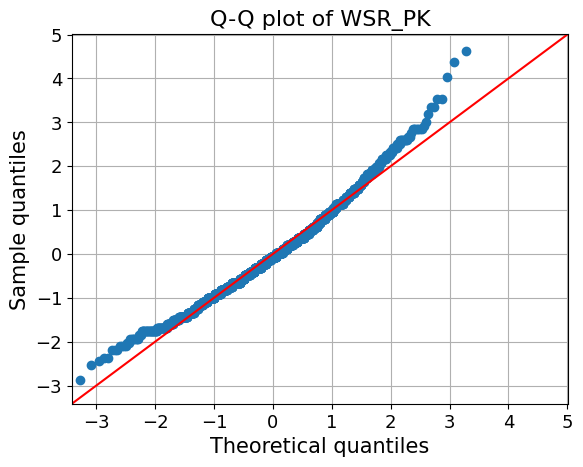

<Figure size 500x300 with 0 Axes>

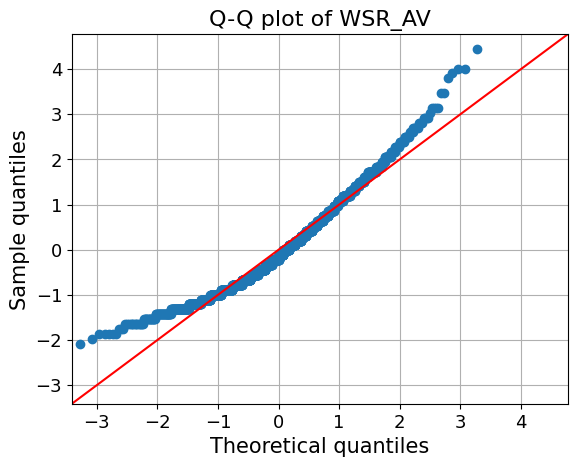

<Figure size 500x300 with 0 Axes>

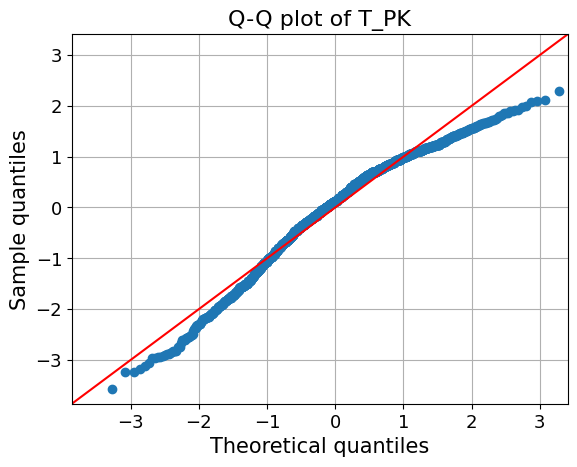

<Figure size 500x300 with 0 Axes>

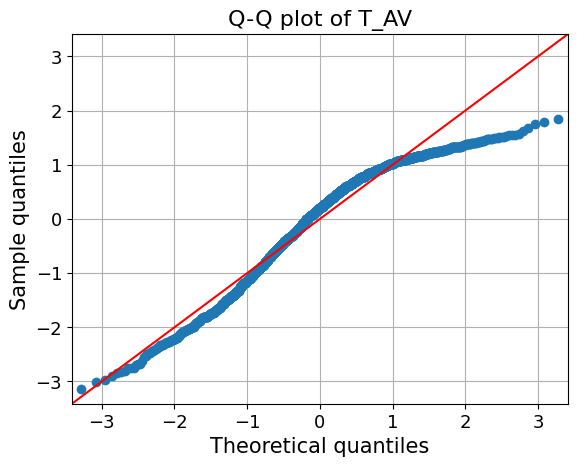

<Figure size 500x300 with 0 Axes>

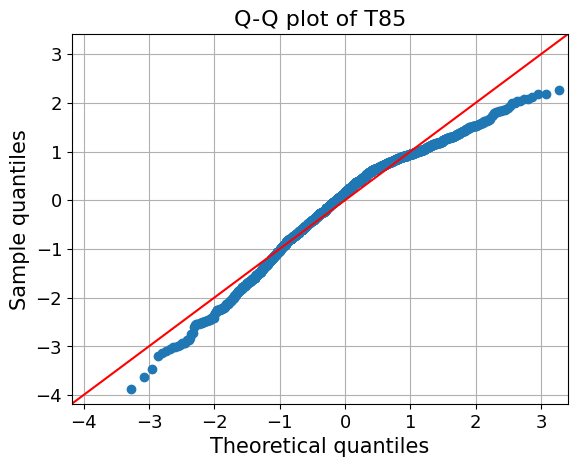

<Figure size 500x300 with 0 Axes>

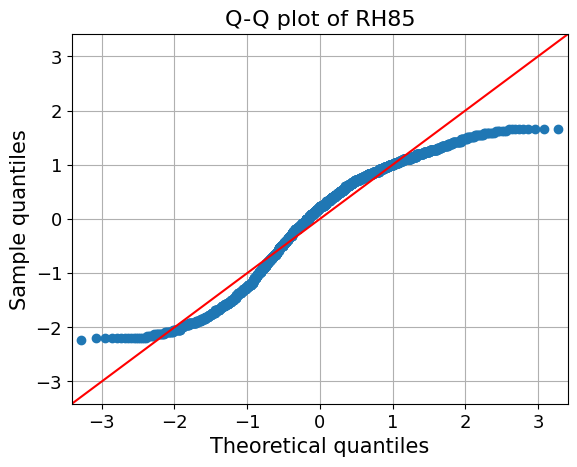

<Figure size 500x300 with 0 Axes>

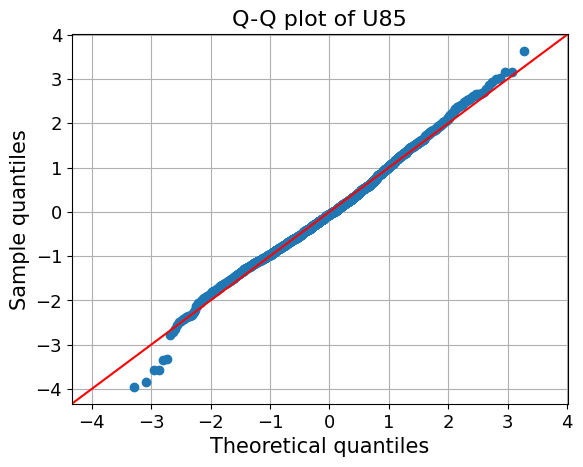

<Figure size 500x300 with 0 Axes>

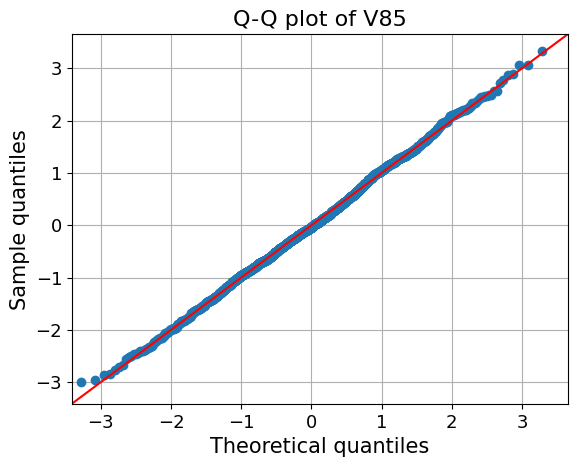

<Figure size 500x300 with 0 Axes>

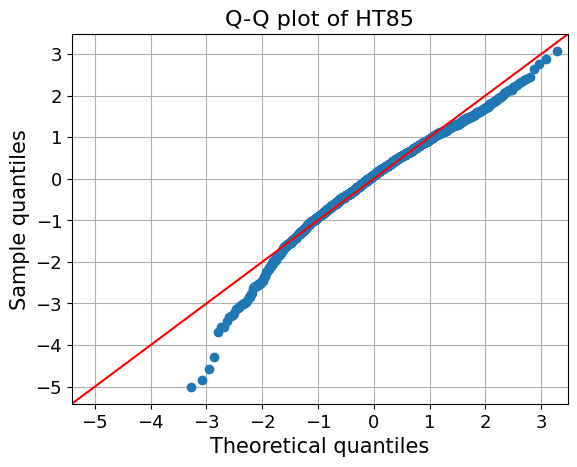

<Figure size 500x300 with 0 Axes>

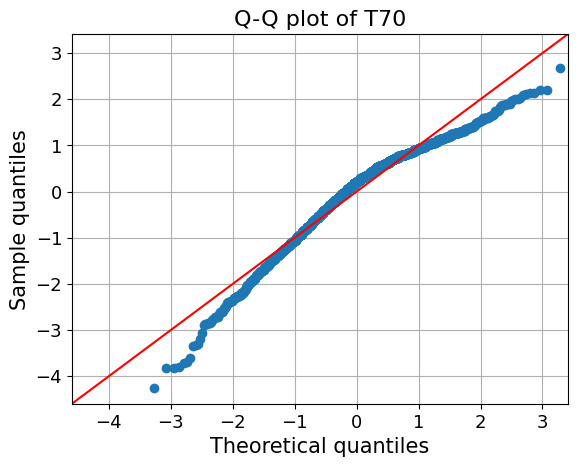

<Figure size 500x300 with 0 Axes>

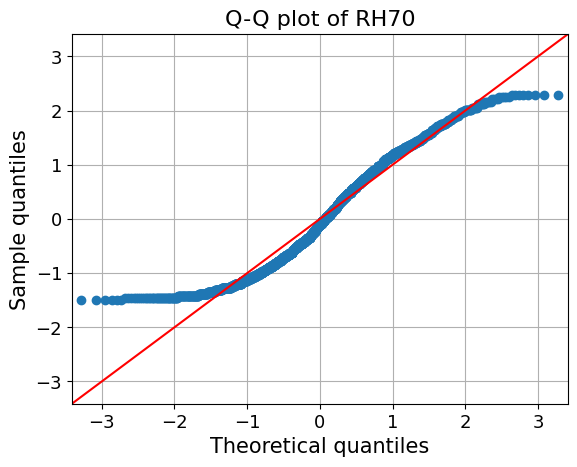

<Figure size 500x300 with 0 Axes>

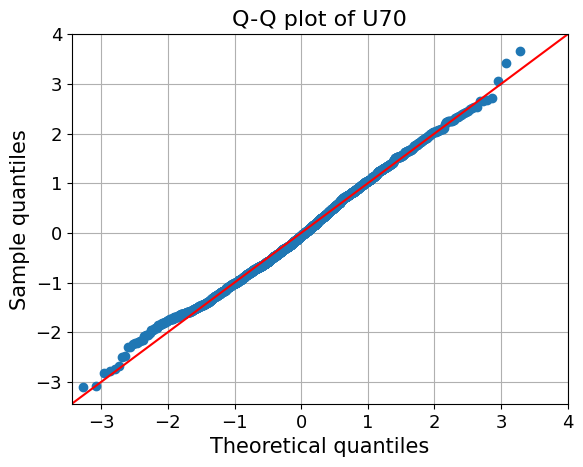

<Figure size 500x300 with 0 Axes>

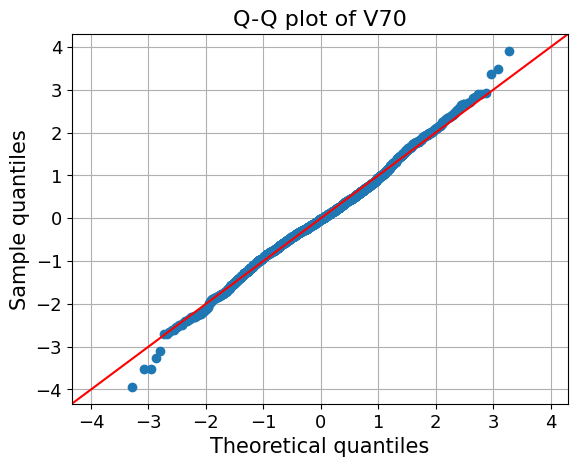

<Figure size 500x300 with 0 Axes>

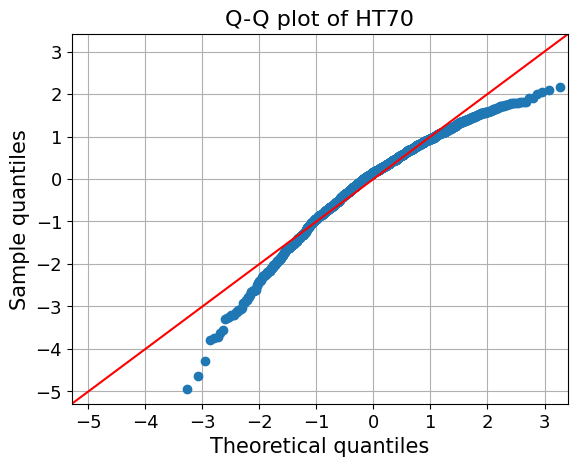

<Figure size 500x300 with 0 Axes>

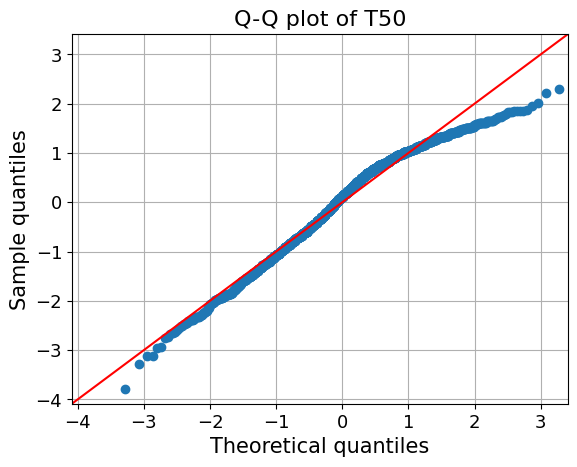

<Figure size 500x300 with 0 Axes>

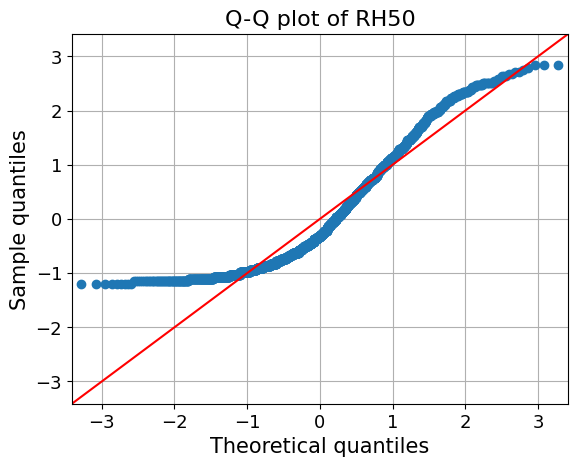

<Figure size 500x300 with 0 Axes>

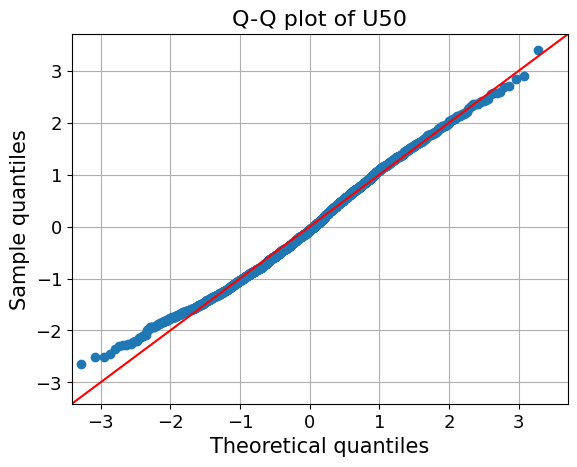

<Figure size 500x300 with 0 Axes>

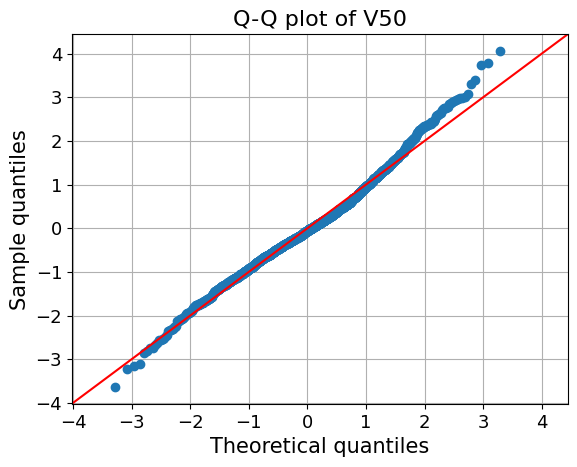

<Figure size 500x300 with 0 Axes>

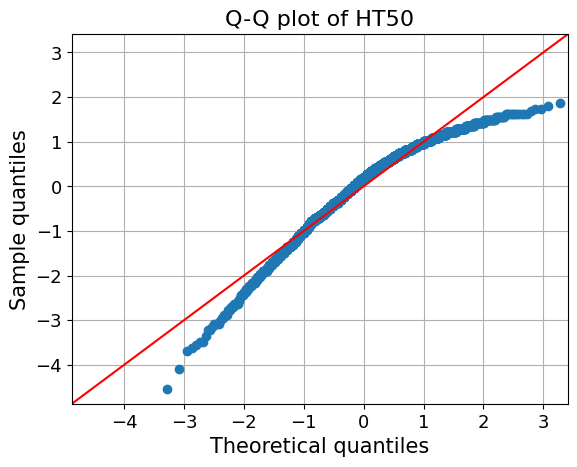

<Figure size 500x300 with 0 Axes>

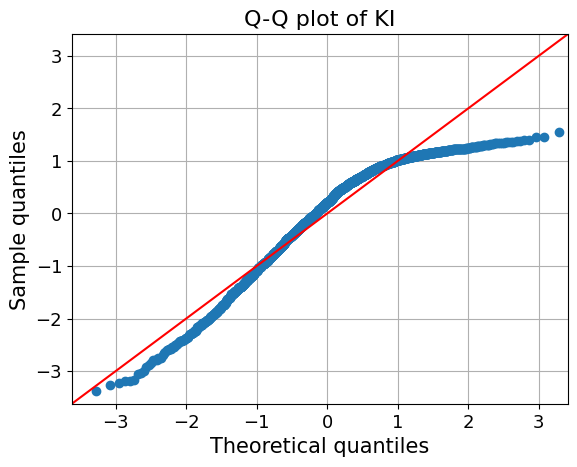

<Figure size 500x300 with 0 Axes>

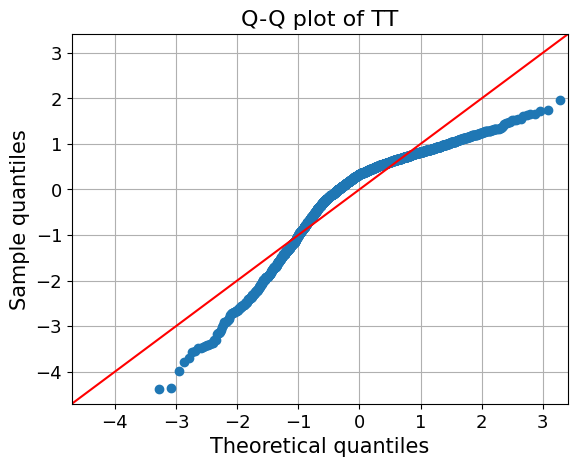

<Figure size 500x300 with 0 Axes>

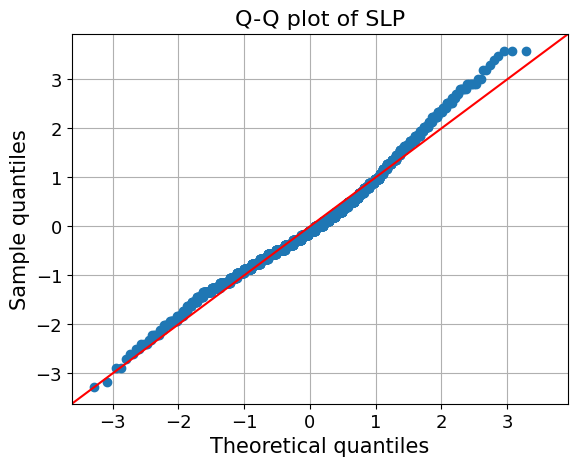

<Figure size 500x300 with 0 Axes>

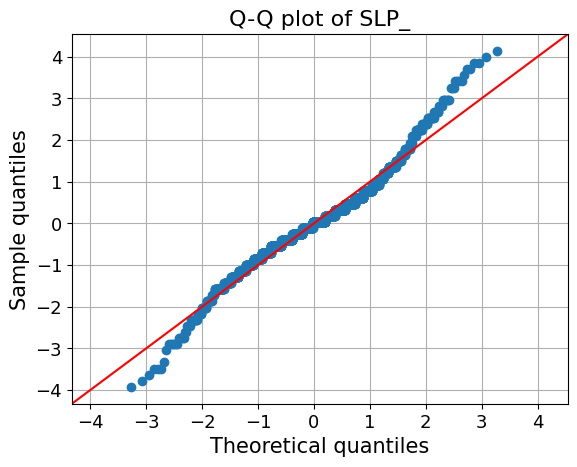

<Figure size 500x300 with 0 Axes>

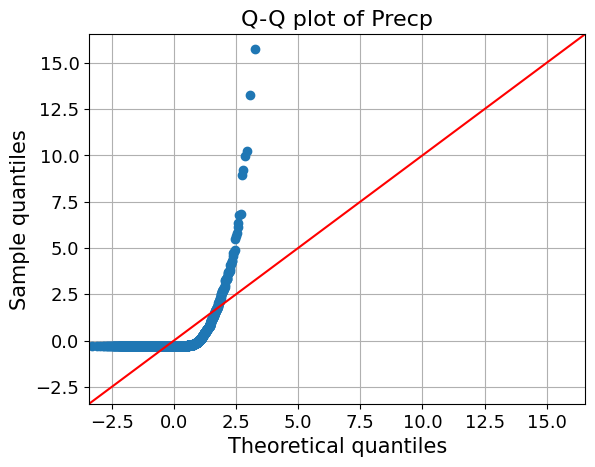

In [25]:
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
import numpy as np

for c in df_nan.columns[:24]:

    # Convert to numeric safely
    col_data = (
        pd.to_numeric(df_nan[c], errors='coerce')  # converts '?' → NaN
          .replace([np.inf, -np.inf], np.nan)
          .dropna()
    )

    # Skip columns with no valid data
    if col_data.empty:
        continue

    plt.figure(figsize=(5,3))
    qqplot(col_data, line='45', fit=True)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.xlabel("Theoretical quantiles", fontsize=15)
    plt.ylabel("Sample quantiles", fontsize=15)
    plt.title(f"Q-Q plot of {c}", fontsize=16)
    plt.grid(True)
    plt.show()

  



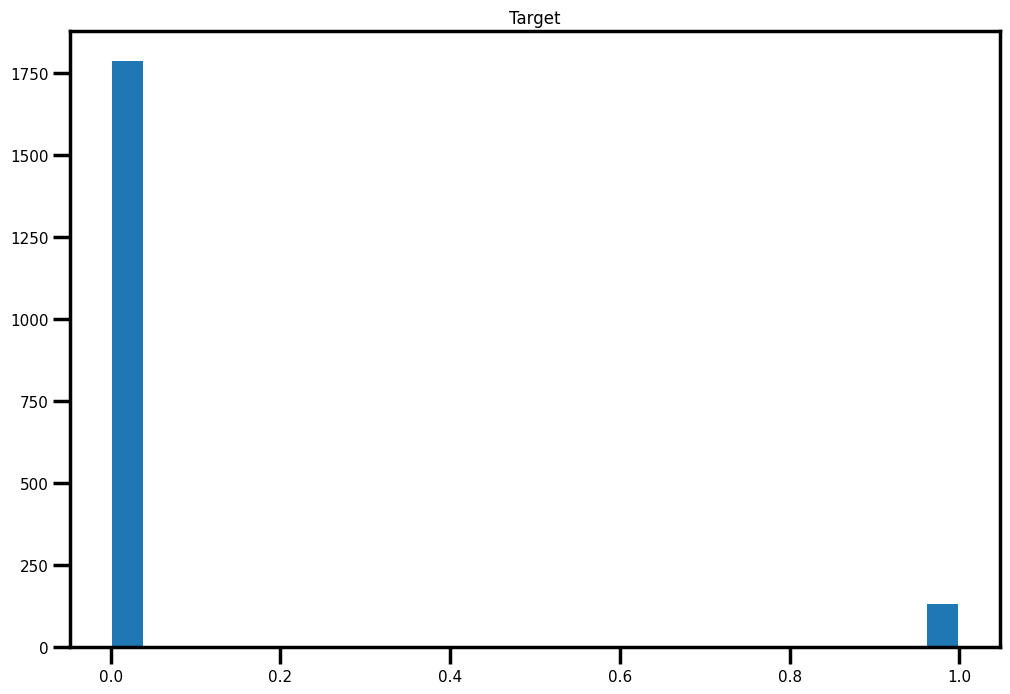

In [26]:
#Plotting the histogram for each column to check the distributions of all the variables
sns.set_context('poster', font_scale=0.5)
df_nan.hist(bins=25, grid=False, figsize=(12,8), zorder=2, rwidth=0.9)
plt.show()


## We can see that each attribute has a different kind of distribution as follows
1. Normal Distribution - U85, V85, U70, V70, U50, V50, SLP, SLP_
2. Left Skewed Distribution - WSR_PK, WSR_AV, RH50
3. Rigth Skewed Distribution - T_PK, T_AV, T85, HT85, T70, HT70, HT50, KI,TT
4. Bimodal Distribution - RH85, RH70, T50
5. None - Precp


# Data Normalization
Also checking the ranges of all the variables.

<Axes: >

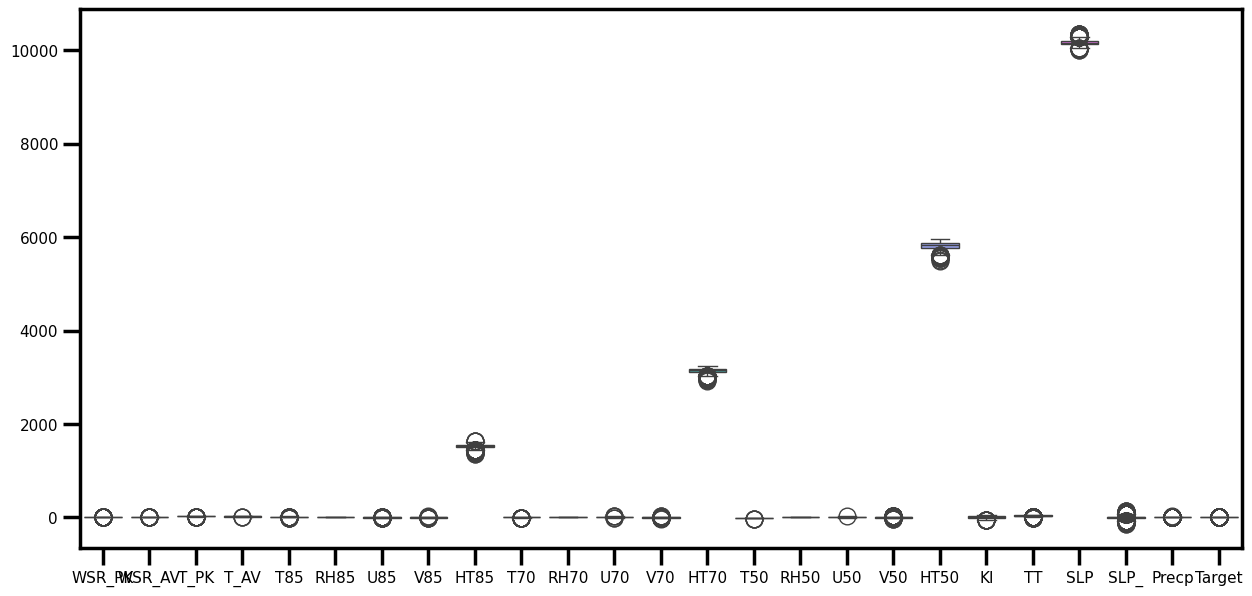

In [27]:
#Plotting boxplot
plt.figure(figsize=(15,7))
sns.boxplot(data=df_nan)

In [28]:
#Normalizing values for the attributes HT85, HT70, HT50, SLP as they have really furthered values from others

from sklearn import preprocessing
data = df_nan.copy(deep=True)

# Create x to store scaled values as floats
x = data[['HT85','HT70','HT50','SLP']].values.astype(float)

# Preparing for normalizing
min_max_scaler = preprocessing.MinMaxScaler()

# Transform the data to fit minmax processor
x_scaled = min_max_scaler.fit_transform(x)

# Run the normalizer on the dataframe
data[['HT85','HT70','HT50','SLP']] = pd.DataFrame(x_scaled)

<Axes: >

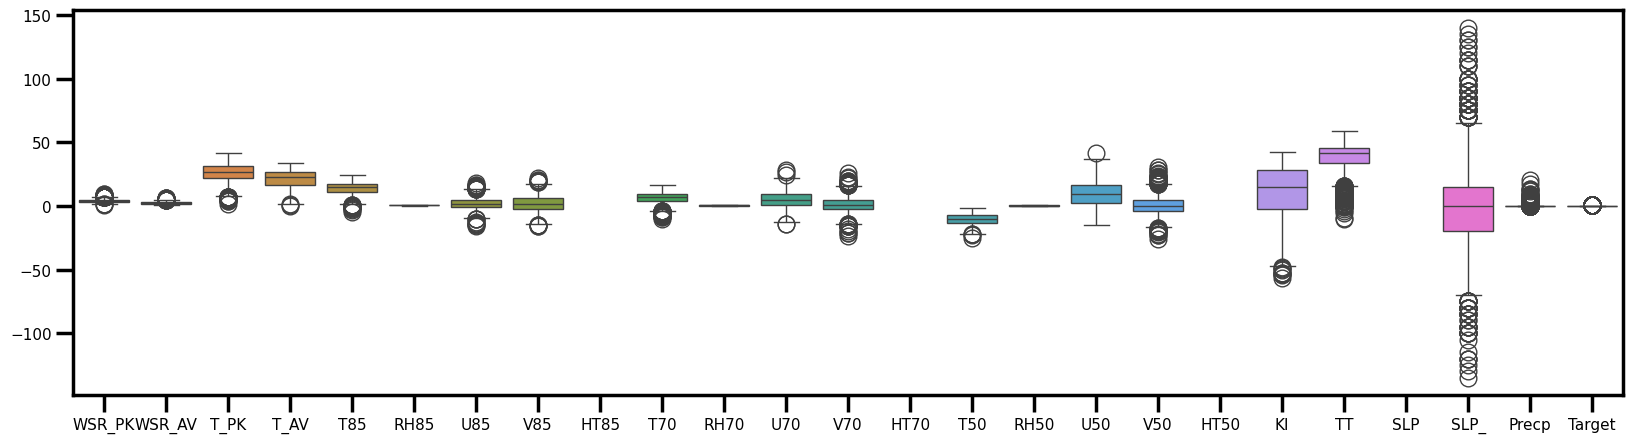

In [29]:
#Plotting the boxplot

plt.figure(figsize=(20,5))
sns.boxplot(data=data)

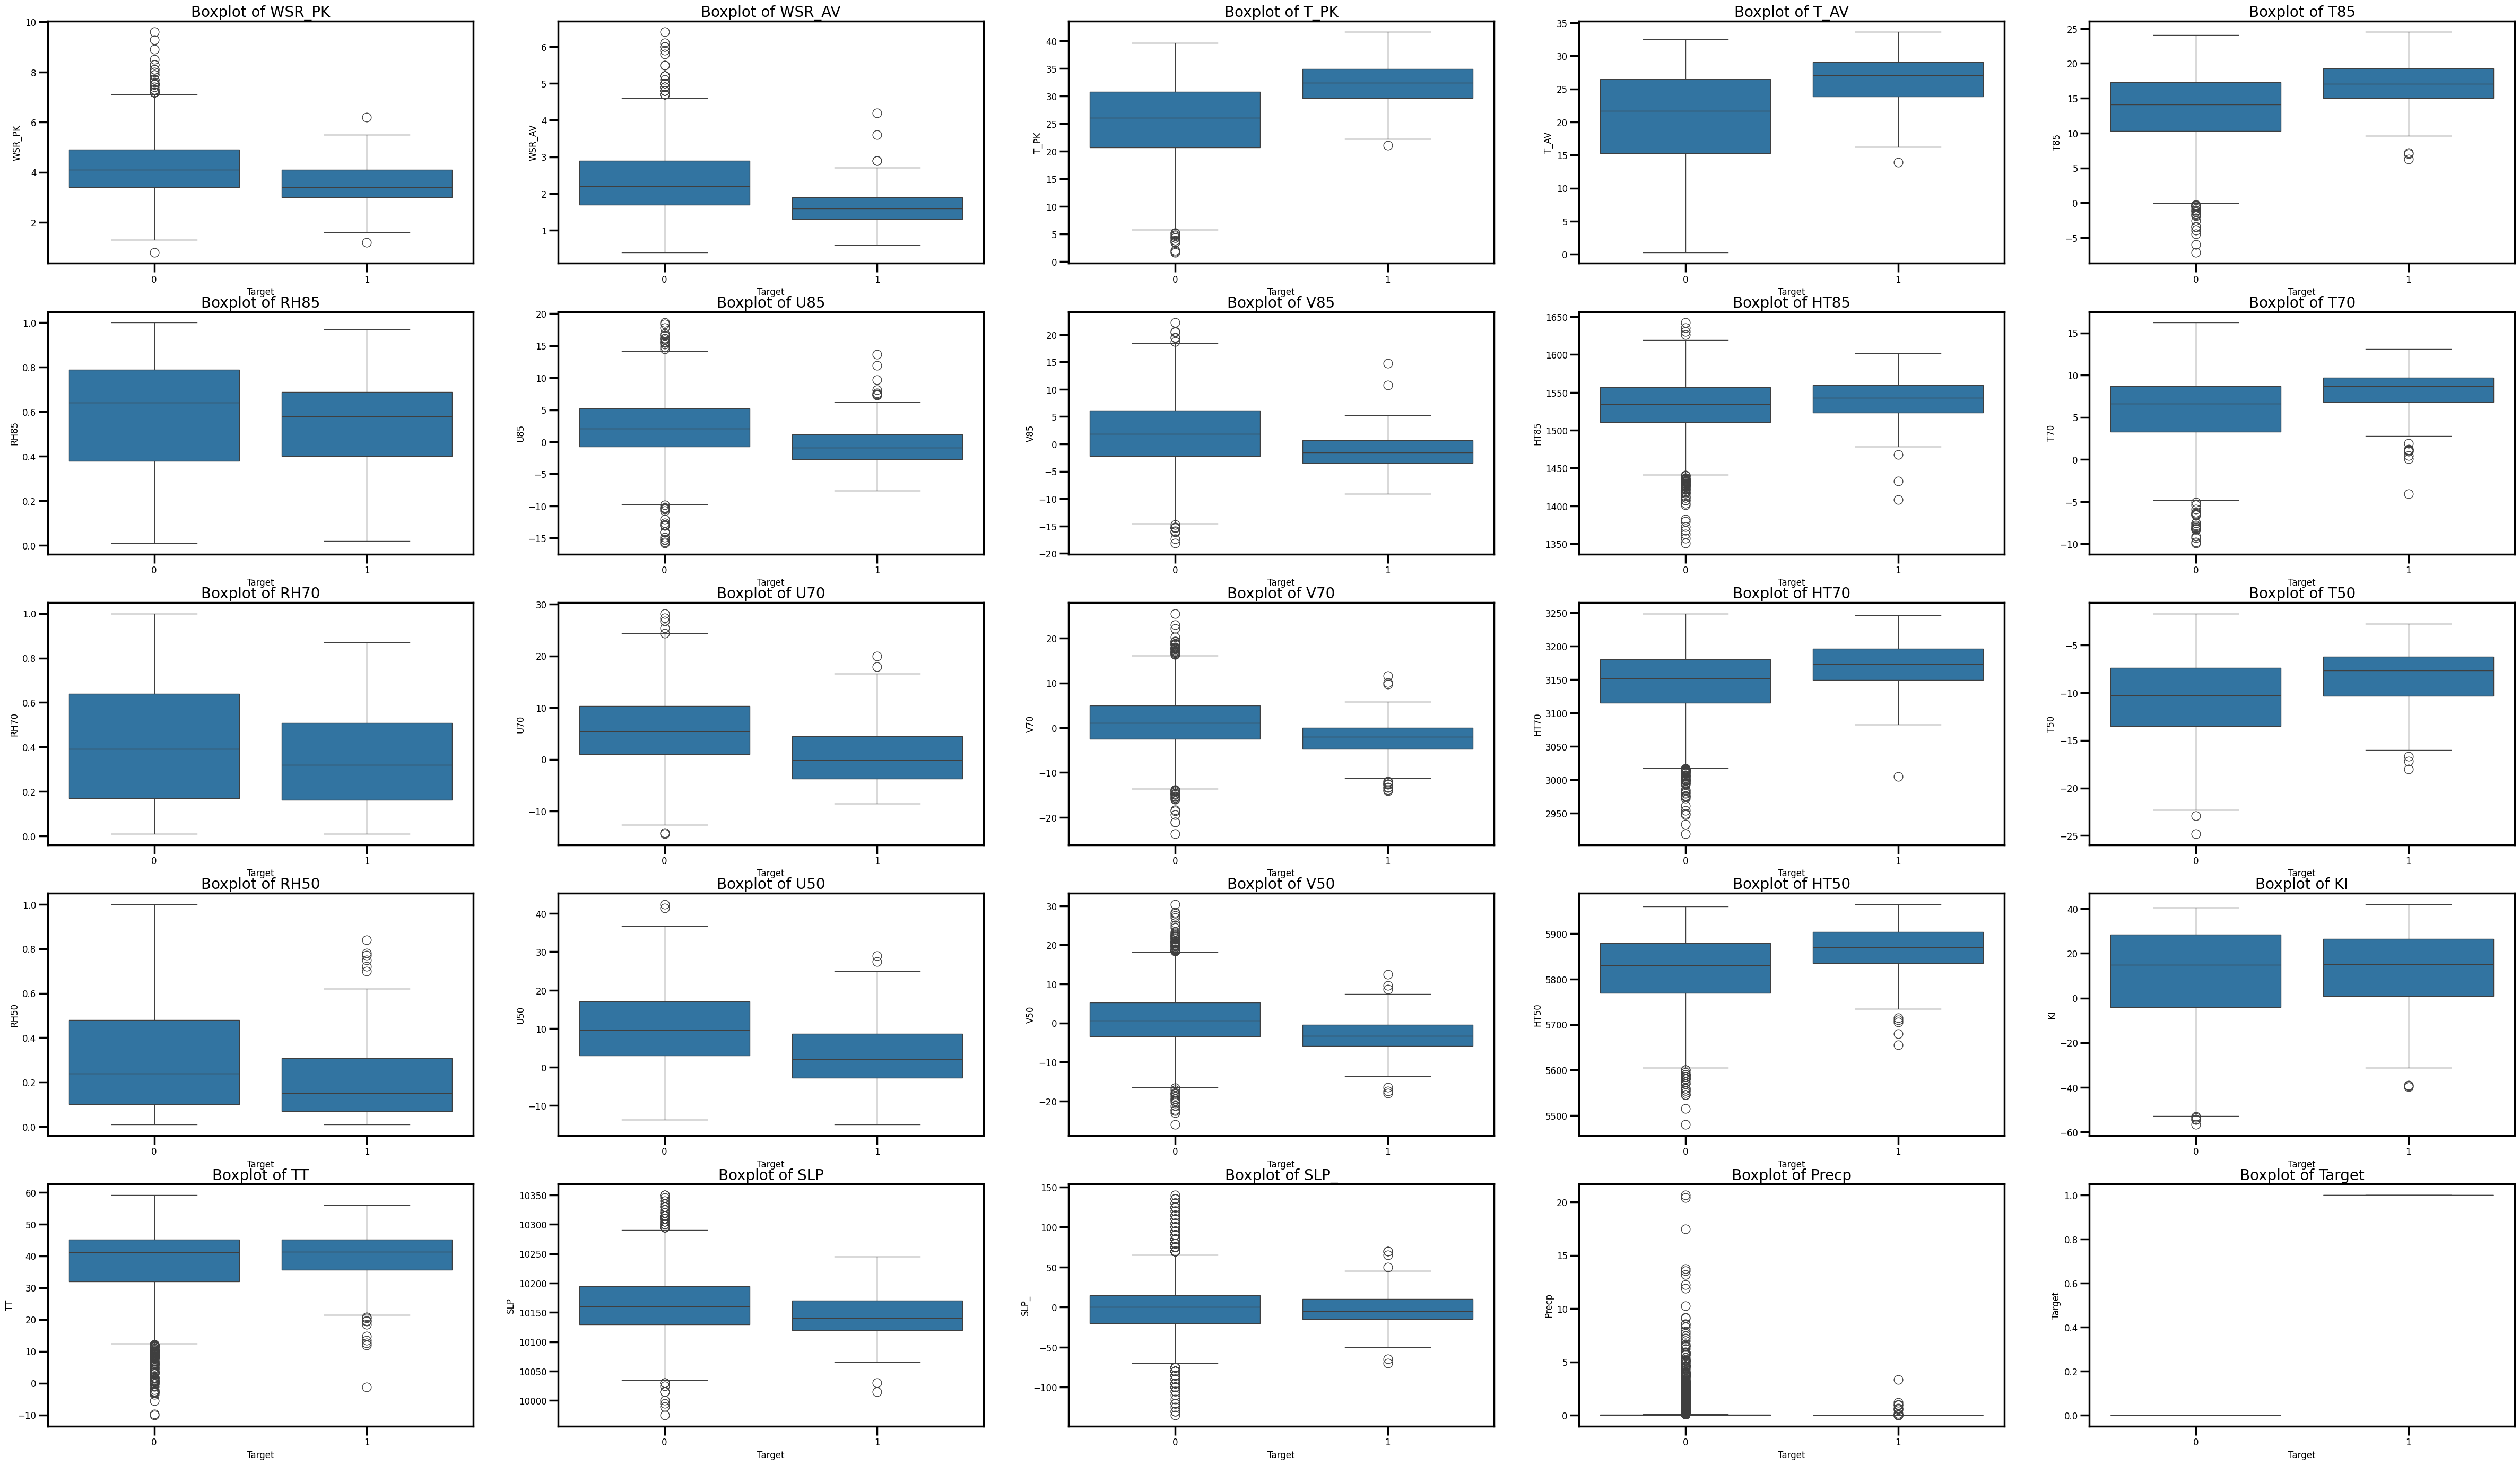

In [30]:
# Plotting one to one boxplots to check the ranges of the variables
i=1
plt.figure(figsize=(60,70))
for c in df_nan.columns[:]:
    plt.subplot(10,5,i)
    plt.title(f"Boxplot of {c}",fontsize=20)
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    sns.boxplot(y=df[c],x=df['Target'])
    i+=1
plt.show()

Looking at both of these we can see that there are multiple variables which have a lot of outliers and hence we needed to check each of it directly comparing it to target as the second figure.

In [31]:
#Checking the correlation of all the variables.

df_cor = df_nan.corr()
df_cor

,WSR_PK,WSR_AV,T_PK,T_AV,T85,RH85,U85,V85,HT85,T70,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
WSR_PK,1.000000,0.849946,-0.174488,-0.134402,-0.102427,0.015157,0.176817,0.394662,-0.264643,-0.095297,...,0.027134,0.214737,0.262752,-0.238007,-0.021611,0.064428,-0.124441,-0.233094,0.114146,-0.147723
WSR_AV,0.849946,1.000000,-0.240992,-0.158223,-0.091537,0.046702,0.185500,0.473110,-0.251166,-0.049570,...,0.044351,0.242955,0.291937,-0.205589,-0.004619,0.080842,-0.097676,-0.207776,0.065014,-0.189431
T_PK,-0.174488,-0.240992,1.000000,0.970093,0.828486,0.181790,-0.332086,0.144719,0.269344,0.745108,...,0.000746,-0.674495,-0.237436,0.748560,0.409946,0.389313,-0.467146,-0.138014,-0.060078,0.247542
T_AV,-0.134402,-0.158223,0.970093,1.000000,0.861881,0.282120,-0.348864,0.250684,0.265031,0.780260,...,0.083685,-0.683590,-0.157070,0.777246,0.501062,0.473882,-0.500812,-0.164845,-0.012346,0.198690
T85,-0.102427,-0.091537,0.828486,0.861881,1.000000,0.211252,-0.271255,0.310744,0.187944,0.866858,...,0.139968,-0.614105,0.002544,0.810546,0.542239,0.473423,-0.573026,-0.127280,0.047815,0.175191
RH85,0.015157,0.046702,0.181790,0.282120,0.211252,1.000000,-0.033502,0.308218,-0.075664,0.165826,...,0.326113,-0.167892,0.276888,0.152254,0.752037,0.815644,-0.357724,-0.220511,0.175613,-0.036175
U85,0.176817,0.185500,-0.332086,-0.348864,-0.271255,-0.033502,1.000000,0.103763,-0.420280,-0.268098,...,-0.020347,0.636652,0.186533,-0.447214,-0.111435,0.001859,-0.096451,-0.093115,-0.042695,-0.139187
V85,0.394662,0.473110,0.144719,0.250684,0.310744,0.308218,0.103763,1.000000,-0.123081,0.316997,...,0.221215,-0.033771,0.538590,0.166927,0.306352,0.375883,-0.331880,-0.446421,0.195164,-0.149121
HT85,-0.264643,-0.251166,0.269344,0.265031,0.187944,-0.075664,-0.420280,-0.123081,1.000000,0.190987,...,-0.032923,-0.463137,-0.314824,0.645742,-0.002662,-0.095929,0.654885,0.225198,-0.049705,0.060095
T70,-0.095297,-0.049570,0.745108,0.780260,0.866858,0.165826,-0.268098,0.316997,0.190987,1.000000,...,0.039710,-0.555517,-0.008990,0.839743,0.280701,0.292770,-0.471511,-0.100263,-0.001266,0.132408


<Axes: >

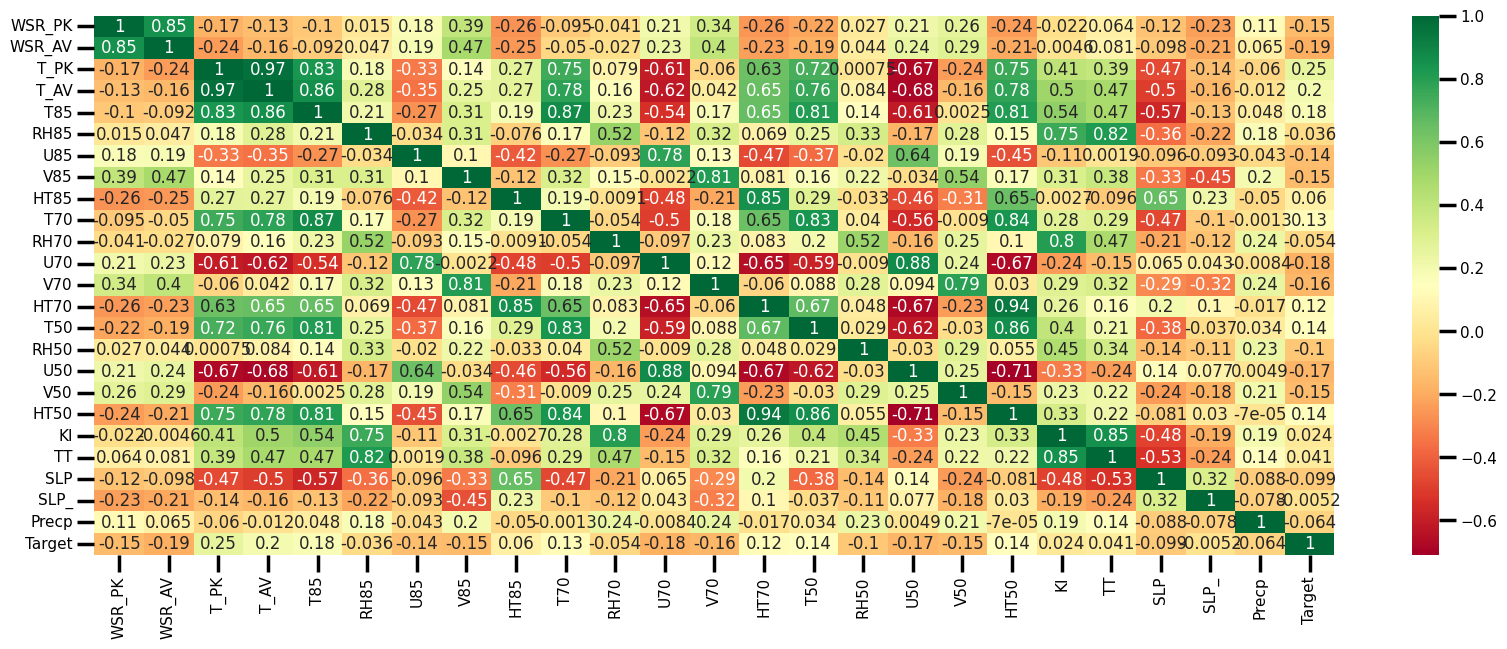

In [32]:
#Heatmap for the correlation of the attributes

plt.figure(figsize=(20,7))
sns.heatmap(df_nan.corr(), annot=True, cmap='RdYlGn')

We have alot of variables which have high correlation such as T_PK with T_AV and T85, HT50 with HT70, T70 and T50 which may say that all these are predicting the same things.

In [33]:
#Correlation with output variable
cor_target = abs(df_cor['T_PK'])
#Selecting highle correlated features
rel_features = cor_target
rel_features

WSR_PK    0.174488
WSR_AV    0.240992
T_PK      1.000000
T_AV      0.970093
T85       0.828486
RH85      0.181790
U85       0.332086
V85       0.144719
HT85      0.269344
T70       0.745108
RH70      0.079359
U70       0.607488
V70       0.060085
HT70      0.634209
T50       0.724056
RH50      0.000746
U50       0.674495
V50       0.237436
HT50      0.748560
KI        0.409946
TT        0.389313
SLP       0.467146
SLP_      0.138014
Precp     0.060078
Target    0.247542
Name: T_PK, dtype: float64

In [34]:
rel_features = cor_target[cor_target>0.8]
rel_features

T_PK    1.000000
T_AV    0.970093
T85     0.828486
Name: T_PK, dtype: float64

In [ ]:
sns.pairplot(df)

# In the predictor variables independent of all the other predictor variables?
There is some correlation between independent variables which might say that they are dependent on each other.
* HT85, HT70, HT50 - Geopotential heights at different altitudes
* T85, T70, T50 - Temperatures at different hpa levels
* KI, TT - K-Index, Total-Totals Index. These are the storm potential and stability index.

#Auto-correlation Function

In [ ]:
#Distributed autocorrelation between predictor and dependent variable
columns = df_nan[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70',
                'U70','V70','HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]
target = df_nan[['Target']]

<Figure size 400x200 with 0 Axes>

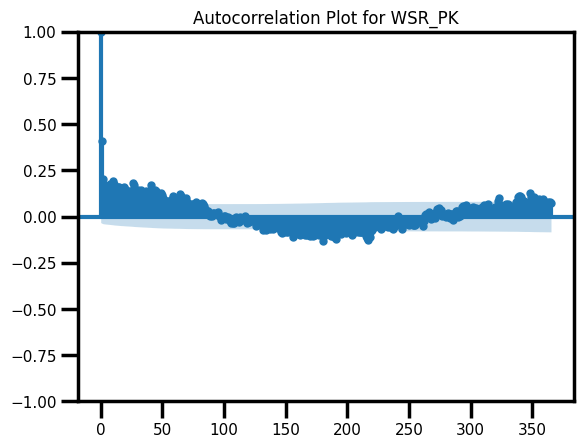

<Figure size 400x200 with 0 Axes>

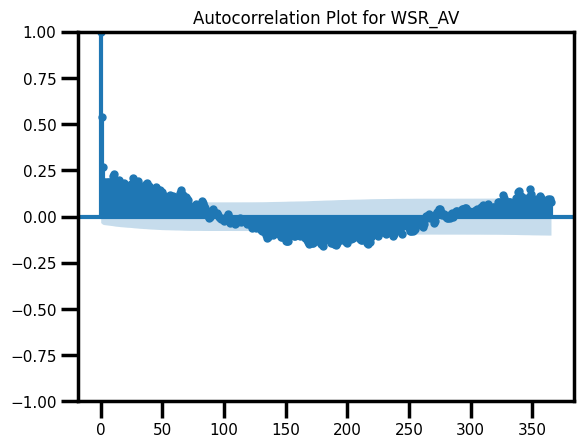

<Figure size 400x200 with 0 Axes>

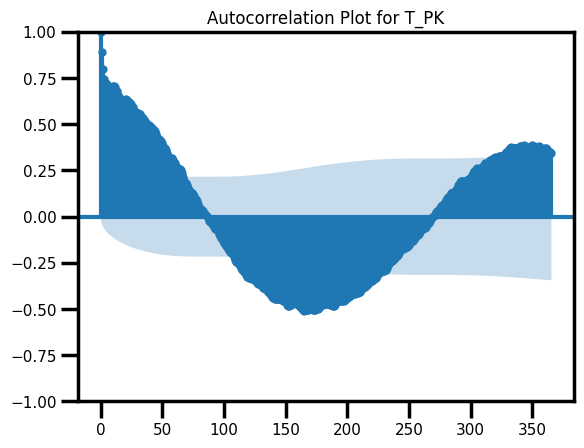

<Figure size 400x200 with 0 Axes>

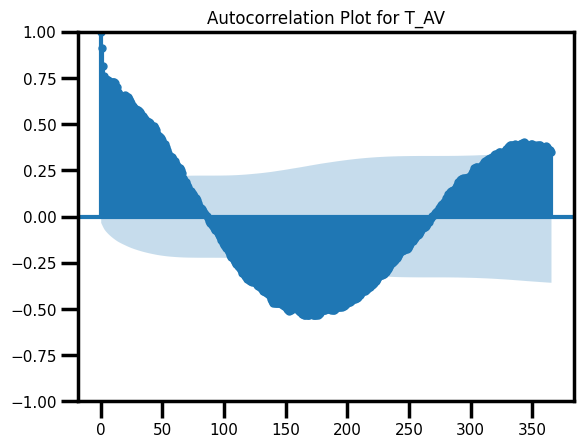

<Figure size 400x200 with 0 Axes>

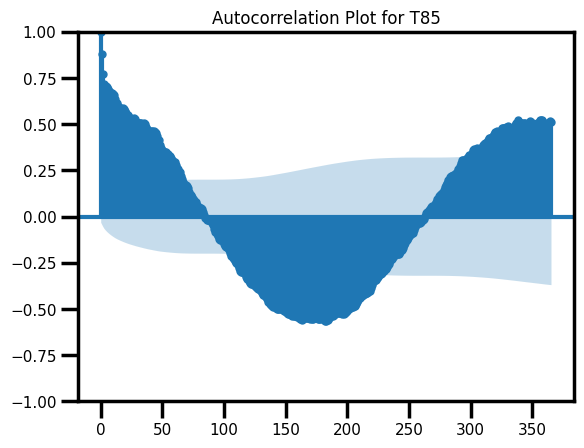

<Figure size 400x200 with 0 Axes>

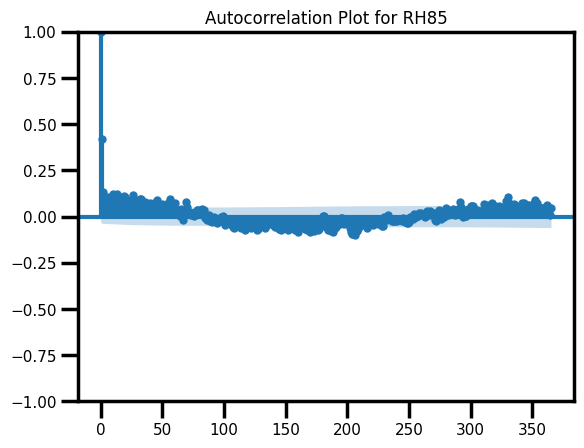

<Figure size 400x200 with 0 Axes>

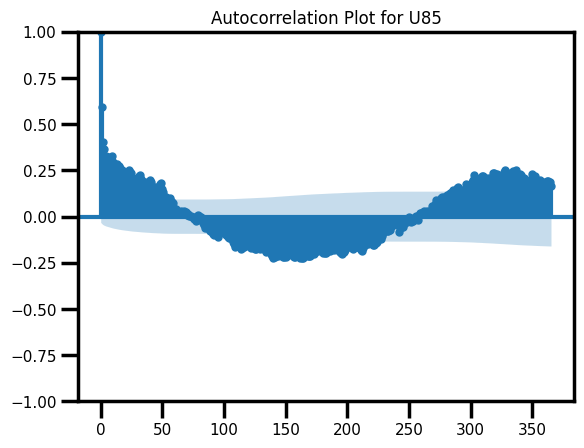

<Figure size 400x200 with 0 Axes>

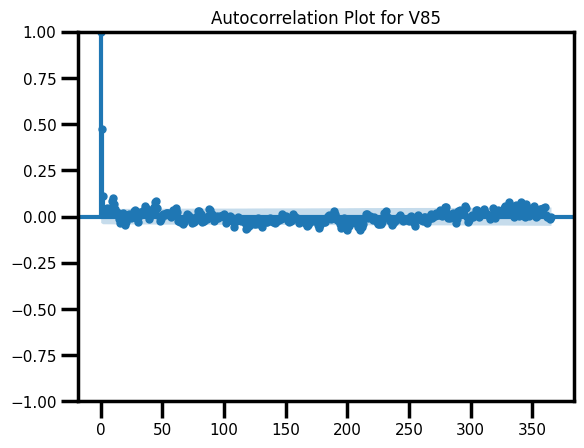

<Figure size 400x200 with 0 Axes>

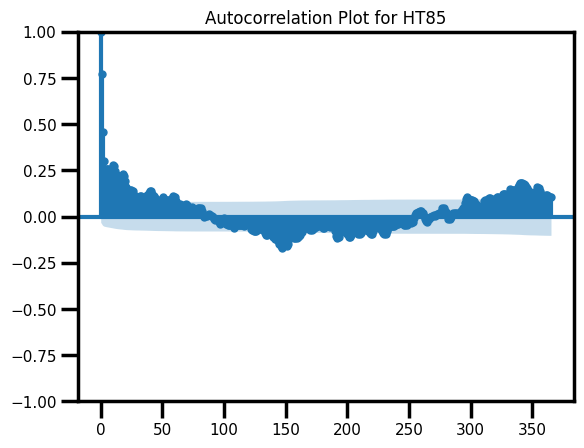

<Figure size 400x200 with 0 Axes>

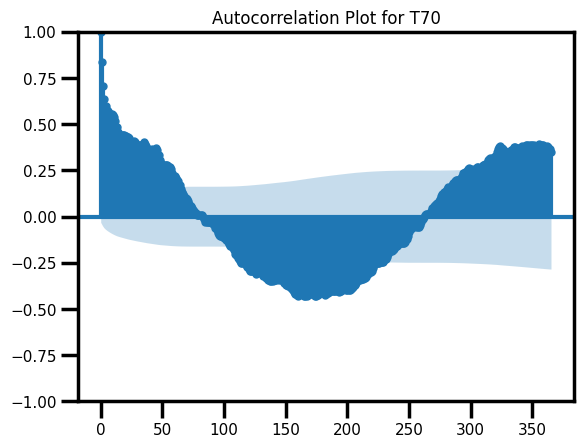

<Figure size 400x200 with 0 Axes>

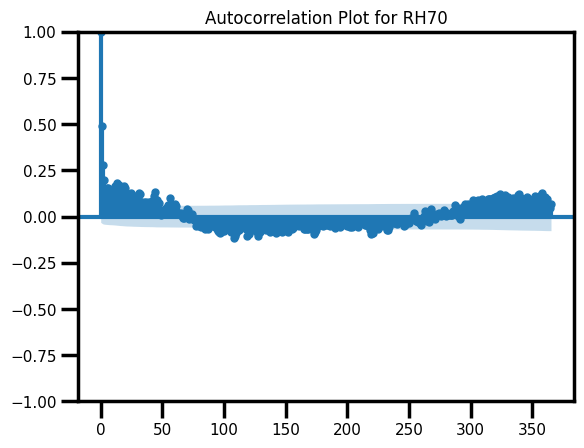

<Figure size 400x200 with 0 Axes>

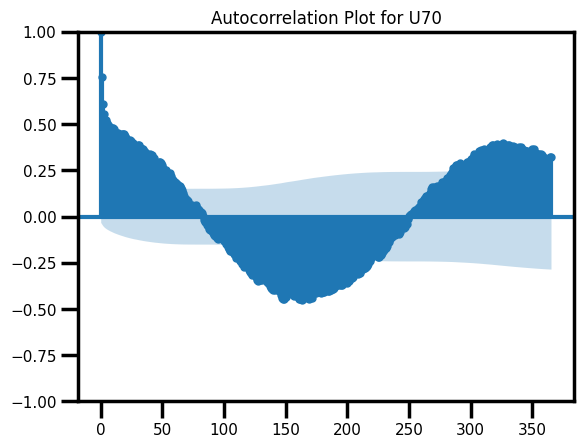

<Figure size 400x200 with 0 Axes>

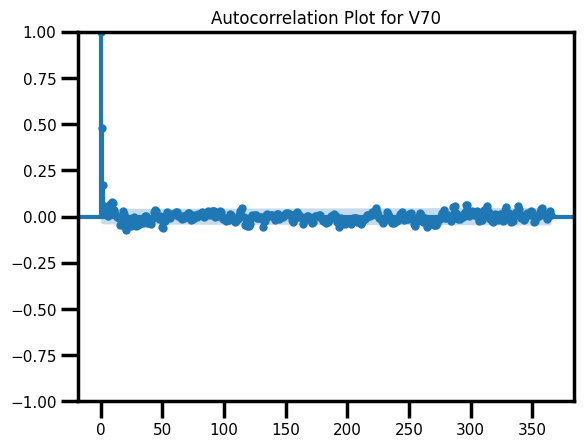

<Figure size 400x200 with 0 Axes>

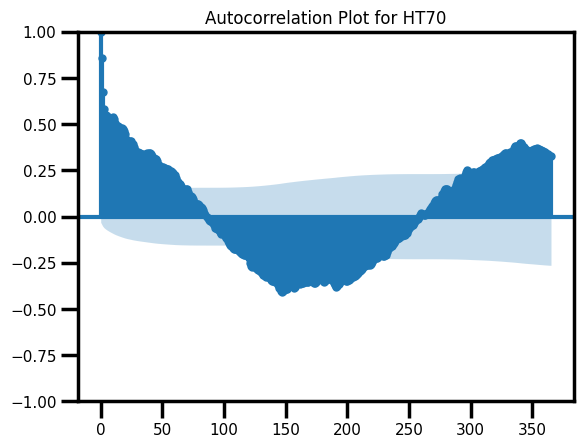

<Figure size 400x200 with 0 Axes>

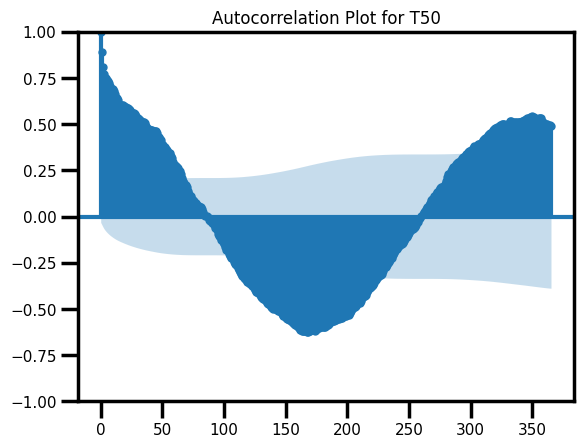

<Figure size 400x200 with 0 Axes>

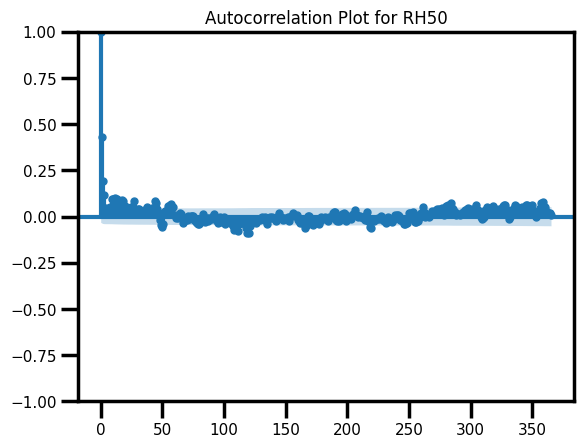

<Figure size 400x200 with 0 Axes>

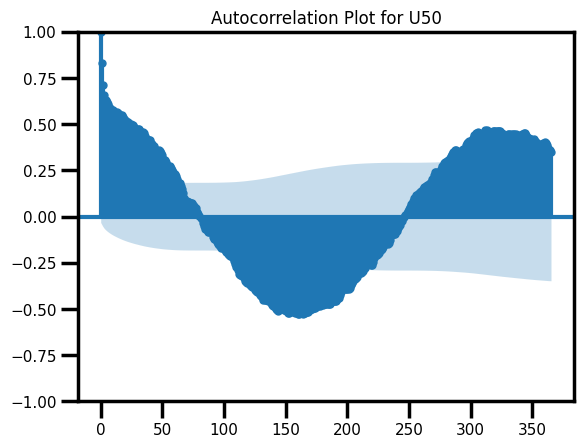

<Figure size 400x200 with 0 Axes>

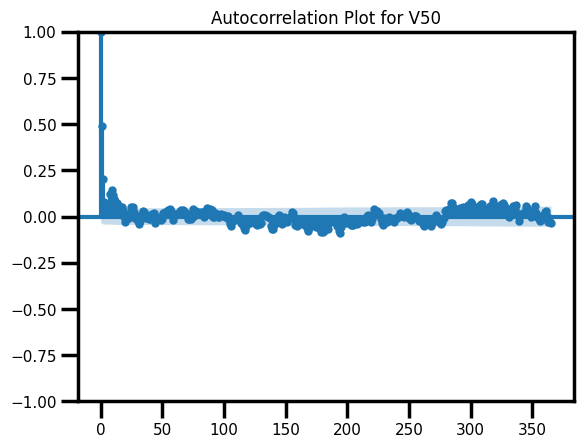

<Figure size 400x200 with 0 Axes>

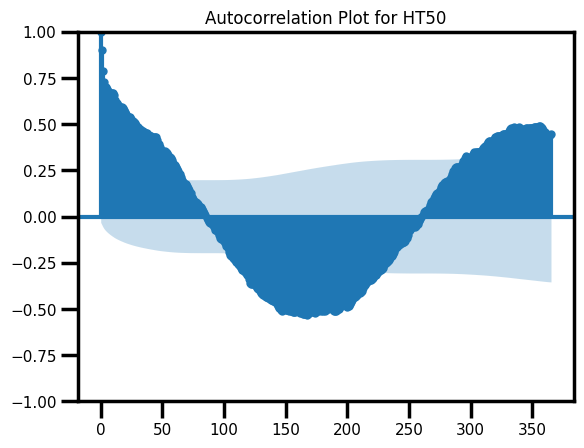

<Figure size 400x200 with 0 Axes>

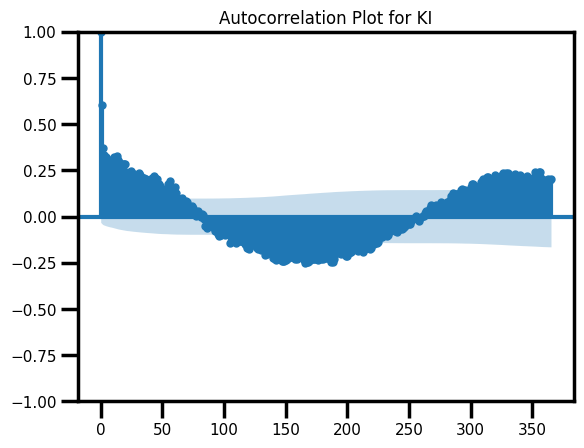

<Figure size 400x200 with 0 Axes>

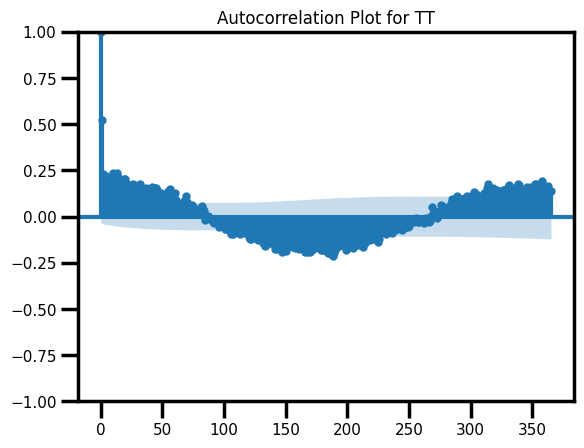

<Figure size 400x200 with 0 Axes>

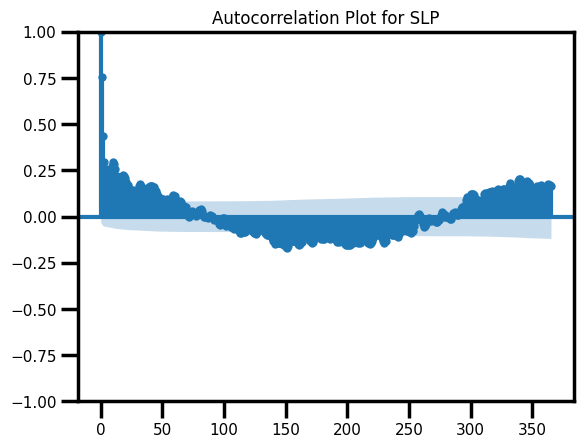

<Figure size 400x200 with 0 Axes>

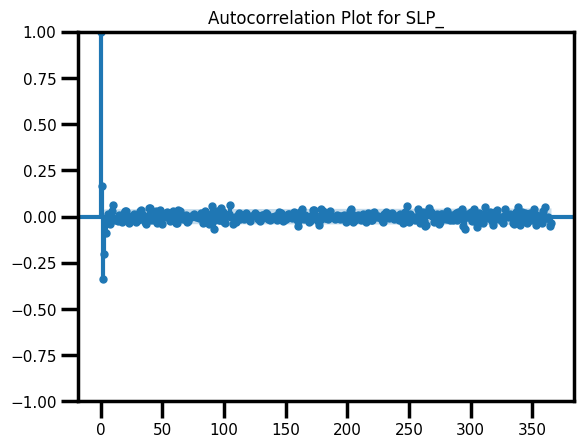

<Figure size 400x200 with 0 Axes>

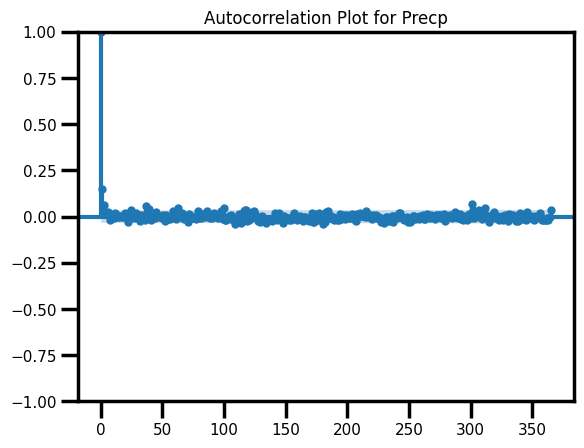

In [ ]:
#Auto-Correlation function
from statsmodels.graphics.tsaplots import plot_acf

for column in columns:
    plt.figure(figsize=(4,2))
    plot_acf(df[column].dropna(), lags=365, alpha=0.1)
    plt.title(f'Autocorrelation Plot for {column}')
    plt.show()

We used plot_acf(), which is AutoCorrelation Function which is usually used in Time Series Data to find out the correlation between the current and lagged version of the data.
In the graph above, the plots/spikes are above the shaded region (confidence level=95%) which mean that it has a significantly positive autocorrelation and hence are important features.

#Building Models

## Identifying predictor significance

In [ ]:
# import statsmodels.api as sm

# model = sm.OLS(df_nan['Target'], df_nan[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
#                                  'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']])
# result = model.fit()
# # Print out the statistics
# print(result.summary())

import pandas as pd
import statsmodels.api as sm
import numpy as np

features = [
    'WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85',
    'T70','RH70','U70','V70','HT70',
    'T50','RH50','U50','V50','HT50',
    'KI','TT','SLP','SLP_','Precp'
]

# Convert Target and features to numeric
df_model = df_nan[['Target'] + features].apply(
    pd.to_numeric, errors='coerce'
)

# Remove rows with NaN / inf
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# Separate X and y
y = df_model['Target']
X = df_model[features]

# Add constant (intercept)
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X)
result = model.fit()

# Print summary
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     11.87
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           7.02e-43
Time:                        01:28:29   Log-Likelihood:                 42.378
No. Observations:                1921   AIC:                            -34.76
Df Residuals:                    1896   BIC:                             104.3
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.8078      7.102      1.803      0.0

P-value says that the significant variables are V85, T_PK, T_AV and SLP_ according to the OLS model.

#Which independent variables are useful to predict a target (dependent variable)? (Use at least three methods)
The three methods I have used are Heatmap, AutoCorrelation and OLS model to find out the significant variables to predict the target.
All of the variables which were found out to be significant are mentioned after every method.

In [ ]:
from sklearn.model_selection import  train_test_split

X = df_nan[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]

y = df_nan['Target']

#Spliting data into Training 76.5%, Validation set 13.5% and Test set 10%

X_t, X_test, y_t, y_test = train_test_split(X, y, test_size=0.1, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_t, y_t, test_size=0.15, random_state=1)
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

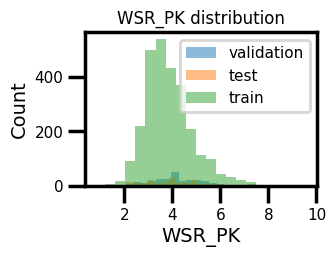

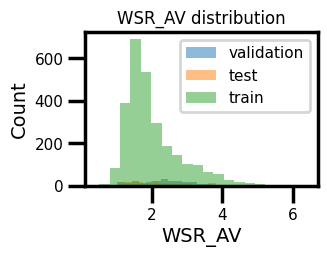

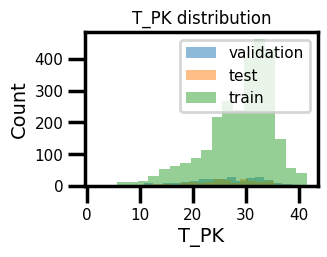

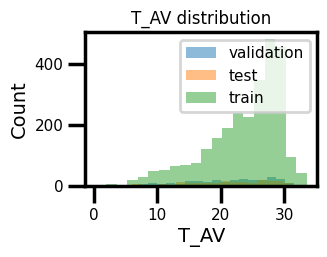

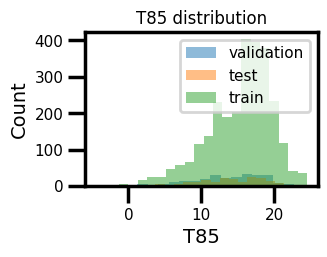

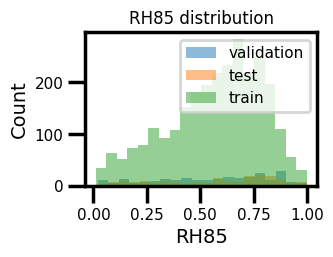

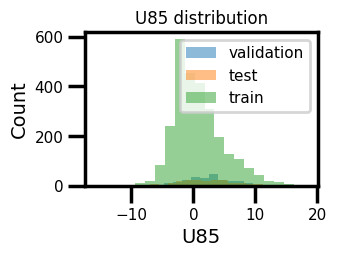

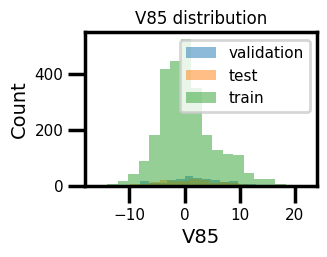

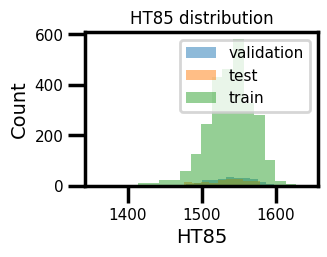

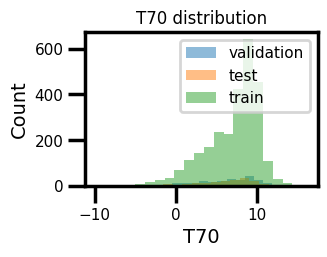

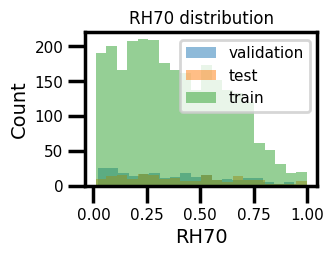

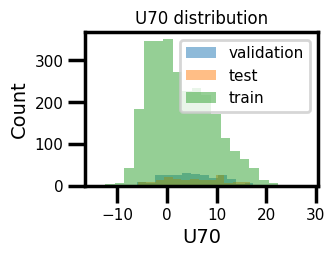

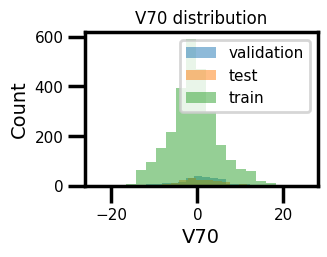

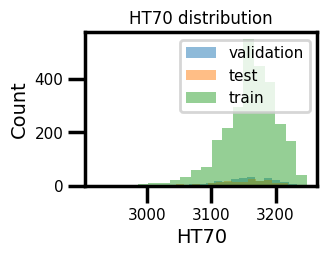

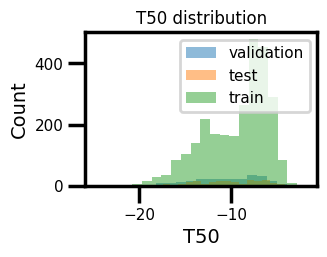

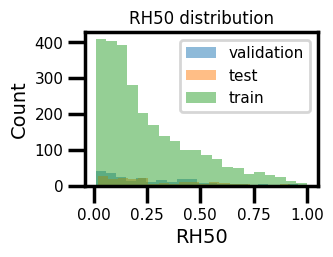

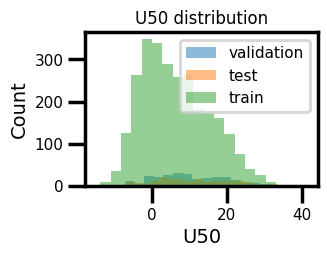

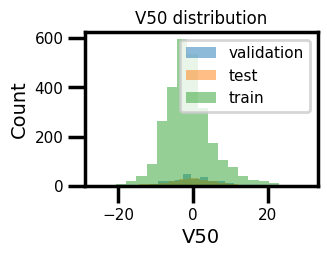

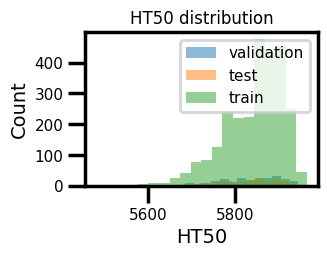

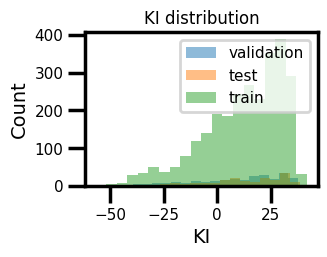

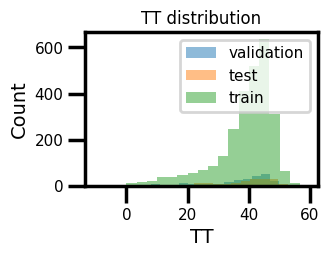

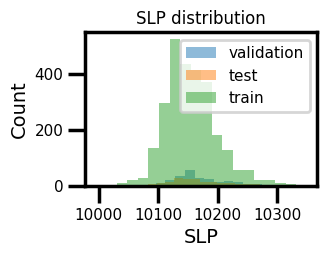

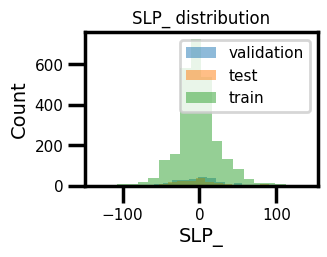

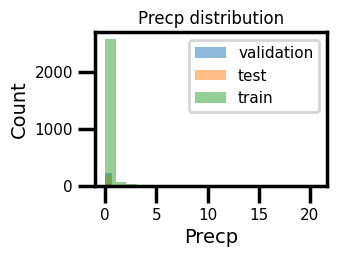

In [ ]:
#Plotting the data distributions acording to test, validation and train data.

X_test_plot = X_test[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]

X_val_plot = X_val[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]

X_train_plot = X_train[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]

# Plotting the data to see the histogram
for c in X_test_plot.columns[:]:
  plt.figure(figsize=(3,2))
  plt.hist(X_val_plot[c], bins=20, alpha=0.5, label="validation")
  plt.hist(X_test_plot[c], bins=20, alpha=0.5, label="test")
  plt.hist(X_train_plot[c], bins=20, alpha=0.5, label="train")
  plt.xlabel(c, size=14)
  plt.ylabel("Count", size=14)
  plt.legend(loc='upper right')
  plt.title("{} distribution".format(c))
  plt.show()

We can see the data we are using ton train our model is equally distributed from the dataframe yet some of the extremities arent covered.

#Do the training and test sets have the same data?
Ans- No, the training and test data sets are typically different. The training data set is used to train the model, while the test data set is used to evaluate the performance of the trained model. The test data set is typically a smaller and independent set of data, that is not used during the training process, and is used to give an unbiased estimate of the model's performance on unseen data.

#Making Predictions

##Linear Regression

In [ ]:
# from sklearn.metrics import r2_score, mean_squared_error 
# # from sklearn.linear_model import LinearRegression
# from sklearn import datasets, linear_model

In [ ]:
#regr = linear_model.LinearRegression()

# # Train the model using the training sets
#regr.fit(X_train,y_train)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.95      0.96       185
           1       0.25      0.38      0.30         8

    accuracy                           0.93       193
   macro avg       0.61      0.66      0.63       193
weighted avg       0.94      0.93      0.93       193



In [ ]:
# Make predictions using the training set
# y_pred = regr.predict(X_train)
# # The mean squared error
# print('Mean squared error: %.2f'% mean_squared_error(y_train, y_pred))
# # The coefficient of determination: 1 is perfect prediction
# print('Coefficient of determination: %.2f'% r2_score(y_train, y_pred))
# r2 = r2_score(y_train,y_pred)
# print('R^2 score on tarining set =',r2)

In [ ]:
# # Make predictions using the testing set
# y_pred = regr.predict(X_test)
# # The mean squared error
# print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred))
# # The coefficient of determination: 1 is perfect prediction
# print('Coefficient of determination: %.2f'% r2_score(y_test, y_pred))
# r2 = r2_score(y_test,y_pred)
# print('R^2 score on test set =',r2)

In [ ]:
# # Make predictions using the validation set
# y_pred = regr.predict(X_val)

# # The mean squared error
# print('Mean squared error: %.2f'% mean_squared_error(y_val, y_pred))
# # The coefficient of determination: 1 is perfect prediction
# print('Coefficient of determination: %.2f'% r2_score(y_val, y_pred))
# r2_val = r2_score(y_val,y_pred)
# print('R^2 score on validation set =',r2_val)

##Decision Tree

In [ ]:
#Decision Tree
#First with the outliers
dfw_outliers = df_nan.copy(deep=True)
dfw_outliers

,WSR_PK,WSR_AV,T_PK,T_AV,T85,RH85,U85,V85,HT85,T70,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Target
Date,,,,,,,,,,,,,,,,,,,,,
1/1/1998,5.5,3.1,19.1,12.5,6.7,0.11,3.83,0.14,1612.0,-2.3,...,0.15,10.67,-1.56,5795.0,-12.1,17.9,10330.0,-55.0,0.0,0
1/2/1998,5.5,3.4,22.4,17.8,9.0,0.25,-0.41,9.53,1594.5,-2.2,...,0.48,8.39,3.84,5805.0,14.05,29.0,10275.0,-55.0,0.0,0
1/3/1998,5.6,3.5,22.2,18.7,9.0,0.56,0.89,10.17,1568.5,0.9,...,0.6,6.94,9.8,5790.0,17.9,41.3,10235.0,-40.0,0.0,0
1/4/1998,4.7,3.2,19.6,18.7,9.9,0.89,-0.34,8.58,1546.5,3.0,...,0.49,8.73,10.54,5775.0,31.15,51.7,10195.0,-40.0,2.08,0
1/7/1998,7.0,5.2,15.8,9.7,12.6,0.98,0.48,7.46,1413.0,4.6,...,0.84,6.86,25.6,5695.0,26.75,48.45,10040.0,-80.0,0.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/27/2004,3.9,1.6,14.8,7.7,5.5,0.33,-2.25,-1.92,1576.0,3.2,...,0.07,7.93,-4.41,5800.0,-25.6,21.8,10295.0,65.0,0.0,0
12/28/2004,5.0,2.6,18.4,12.9,5.8,0.27,-2.45,4.71,1600.5,3.4,...,0.04,5.95,-1.14,5845.0,-19.4,19.1,10310.0,15.0,0.0,0
12/29/2004,3.9,1.9,20.6,17.7,7.5,0.79,7.57,3.13,1591.0,4.6,...,0.06,7.8,-0.64,5845.0,-9.6,35.2,10275.0,-35.0,0.0,0


In [ ]:
#Checking the accuracy using decision tree with outliers
information = dfw_outliers[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]
research = dfw_outliers[['Target']]

X_train, X_test, Y_train, Y_test = train_test_split(information, research, test_size=0.3, random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=10)
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test) 
dec_tree_score = clf.score(X_test, Y_test)
print('Decision Tree ', dec_tree_score)


Decision Tree  0.8942807625649913


In [ ]:
dfw_outliers.shape

(1921, 25)

The Accuracy of the Decision Tree model with the outliers is around 92%.

### IQR Percentile method to remove outliers

In [ ]:
#Remove outliers using IQR Percentile
dfwo_outliers = df_nan.copy(deep=True)

def outliers(dfwo_outliers, column):
    Q1=dfwo_outliers[column].quantile(0.25)
    Q3=dfwo_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound= Q1 - 1.5*IQR
    upper_bound= Q3 + 1.5*IQR
    
    ls = dfwo_outliers.index[ (dfwo_outliers[column] < lower_bound) | (dfwo_outliers[column] > upper_bound)]
    
    return ls

In [ ]:
index_list = []
for column in ['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70ac','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']:
    index_list.extend(outliers(dfwo_outliers,column))


In [ ]:
def remove(dfwo_outliers,ls):
    ls= sorted(set(ls))
    dfwo_outliers=dfwo_outliers.drop(ls)
    return dfwo_outliers

In [ ]:
dfwo_outliers = remove(dfwo_outliers, index_list)

In [ ]:
dfwo_outliers.shape

(1203, 25)

In [ ]:
#Checking the accuracy using decision tree without outliers
information = dfwo_outliers[['WSR_PK','WSR_AV','T_PK','T_AV','T85','RH85','U85','V85','HT85','T70','RH70','U70','V70',
                                 'HT70','T50','RH50','U50','V50','HT50','KI','TT','SLP','SLP_','Precp']]
research = dfwo_outliers[['Target']]

X_train, X_test, Y_train, Y_test = train_test_split(information, research, test_size=0.3, random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=10)
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test) 
dec_tree_score = clf.score(X_test, Y_test)
print('Decision Tree ', dec_tree_score)

Decision Tree  0.8808864265927978


The accuracy falls down to around 90% as we remove the outliers.

#Remove outliers and keep outliers (does if have an effect of the final predictive model)?
We can see that the accuracy dropped around 3% after removing the outliers this is not a big value yet we want as accurate model as we can build so it is better to keep the outliers.

#Imputation of 1%, 5% and 10% of the data after removing and checking its residual

In [ ]:
#As we found out the most significant predictor is T_PK using slider to check the values with time series.
import plotly.express as px

fig = px.line(df_nan, y='T_PK', title= 'T_PK with slider')

fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector=dict(
        buttons= list([
            dict(count=1,label ='1y',stepmode='backward'),
            dict(count=2,label ='2y',stepmode='backward'),
            dict(count=3,label ='3y',stepmode='backward'),
            dict(step='all')
        ])
    )
)
fig.show()

###Removing data around 1%, 5% and 10%.

In [ ]:
#Imputation Process. Remove 1%, 5% and 10% data randomly for column "T_PK"
df_imp1 = df_nan.copy(deep = True)
df_imp5 = df_nan.copy(deep = True)
df_imp10 = df_nan.copy(deep = True)

column_name = "T_PK"

# Calculate the number of rows to remove (1% of the total number of rows)
rows_to_remove_1 = int(df_imp1.shape[0] * 0.01)
rows_to_remove_5 = int(df_imp5.shape[0] * 0.05)
rows_to_remove_10 = int(df_imp10.shape[0] * 0.10)

# Generate a list of random indices to remove
random_indices_1 = np.random.choice(df_imp1.index, rows_to_remove_1, replace=False)
random_indices_5 = np.random.choice(df_imp5.index, rows_to_remove_5, replace=False)
random_indices_10 = np.random.choice(df_imp10.index, rows_to_remove_10, replace=False)


# Remove the data from the target column for the selected indices
df_imp1.loc[random_indices_1, column_name] = np.nan
df_imp5.loc[random_indices_5, column_name] = np.nan
df_imp10.loc[random_indices_10, column_name] = np.nan


In [ ]:
#Checking amount of null values
results = [df_imp1['T_PK'].isnull().sum(), 
           df_imp5['T_PK'].isnull().sum(), 
           df_imp10['T_PK'].isnull().sum()]
print(results)

[np.int64(19), np.int64(96), np.int64(192)]


###Mean Imputation

In [ ]:
# 1] Imputing Mean

df_imp_mean_1 = df_imp1.fillna(df_imp1.mean())
df_imp_mean_5 = df_imp5.fillna(df_imp5.mean())
df_imp_mean_10 = df_imp10.fillna(df_imp10.mean())


C:\Users\kirti\AppData\Local\Temp\ipykernel_21692\3995589255.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\kirti\AppData\Local\Temp\ipykernel_21692\3995589255.py:4: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\kirti\AppData\Local\Temp\ipykernel_21692\3995589255.py:5: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
# Checking the error by calculating the MSE(Mean Squared Error) and RMSE (Root mean squared error)

from sklearn.metrics import mean_squared_error

og_val = df_nan['T_PK'].values

imp_val_1= df_imp_mean_1['T_PK'].values
imp_val_5= df_imp_mean_5['T_PK'].values
imp_val_10= df_imp_mean_10['T_PK'].values

#MSE
mse_1 = mean_squared_error(og_val,imp_val_1)
mse_5 = mean_squared_error(og_val,imp_val_5)
mse_10 = mean_squared_error(og_val,imp_val_10)

#RMSE
rmse_1 = np.sqrt(mse_1)
rmse_5 = np.sqrt(mse_5)
rmse_10 = np.sqrt(mse_10)


print("RMSE for 1% imputation is", rmse_1)
print("RMSE for 5% imputation is", rmse_5)
print("RMSE for 10% imputation is", rmse_10)

RMSE for 1% imputation is 0.8328649789009692
RMSE for 5% imputation is 1.5667729595344644
RMSE for 10% imputation is 2.2449708880367427


This is the root mean squared error for the following imputations

###Linear Interpolation imputation

In [ ]:
# 2] Imputing values using Linear Interpolation

df_imp_li_1 = df_imp1.interpolate(method='linear')
df_imp_li_5 = df_imp5.interpolate(method='linear')
df_imp_li_10 = df_imp10.interpolate(method='linear')


C:\Users\kirti\AppData\Local\Temp\ipykernel_21692\3052319362.py:3: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\kirti\AppData\Local\Temp\ipykernel_21692\3052319362.py:4: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\kirti\AppData\Local\Temp\ipykernel_21692\3052319362.py:5: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.



In [ ]:
# Checking the error by calculating the MSE(Mean Squared Error) and RMSE (Root mean squared error)

og_val = df_nan['T_PK'].values

imp_val_1= df_imp_li_1['T_PK'].values
imp_val_5= df_imp_li_5['T_PK'].values
imp_val_10= df_imp_li_10['T_PK'].values

#MSE
mse_1 = mean_squared_error(og_val,imp_val_1)
mse_5 = mean_squared_error(og_val,imp_val_5)
mse_10 = mean_squared_error(og_val,imp_val_10)

#RMSE
rmse_1 = np.sqrt(mse_1)
rmse_5 = np.sqrt(mse_5)
rmse_10 = np.sqrt(mse_10)


print("RMSE for 1% imputation is", rmse_1)
print("RMSE for 5% imputation is", rmse_5)
print("RMSE for 10% imputation is", rmse_10)


import numpy as np
from sklearn.metrics import mean_squared_error

# Original and imputed columns
og = df_nan['T_PK']
imp1 = df_imp_li_1['T_PK']
imp5 = df_imp_li_5['T_PK']
imp10 = df_imp_li_10['T_PK']

# Mask: where original value exists
mask = og.notna()

# Apply mask
og_val = og[mask].astype(float)
imp_val_1 = imp1[mask].astype(float)
imp_val_5 = imp5[mask].astype(float)
imp_val_10 = imp10[mask].astype(float)

# MSE
mse_1 = mean_squared_error(og_val, imp_val_1)
mse_5 = mean_squared_error(og_val, imp_val_5)
mse_10 = mean_squared_error(og_val, imp_val_10)

# RMSE
rmse_1 = np.sqrt(mse_1)
rmse_5 = np.sqrt(mse_5)
rmse_10 = np.sqrt(mse_10)

print("RMSE for 1% imputation is", rmse_1)
print("RMSE for 5% imputation is", rmse_5)
print("RMSE for 10% imputation is", rmse_10)


ValueError: Input contains NaN.

This is the root mean squared error for this imputation.

###KNN Imputation

In [ ]:
# 3] Imputing values using KNNImputer

from sklearn.impute import KNNImputer as knn

imp_1 = df_imp1['T_PK'].values.reshape(-1,1)
imp_5 = df_imp5['T_PK'].values.reshape(-1,1)
imp_10 = df_imp10['T_PK'].values.reshape(-1,1)

# Impute missing values using KNN imputation
imputer = knn(n_neighbors=5)

imp_knn_1 = imputer.fit_transform(imp_1)
imp_knn_5 = imputer.fit_transform(imp_5)
imp_knn_10 = imputer.fit_transform(imp_10)

In [ ]:
# Checking the error by calculating the MSE(Mean Squared Error) and RMSE (Root mean squared error)

og_val = df_nan['T_PK'].values

#MSE
mse_1 = mean_squared_error(og_val,imp_knn_1)
mse_5 = mean_squared_error(og_val,imp_knn_5)
mse_10 = mean_squared_error(og_val,imp_knn_10)

#RMSE
rmse_1 = np.sqrt(mse_1)
rmse_5 = np.sqrt(mse_5)
rmse_10 = np.sqrt(mse_10)


print("RMSE for 1% imputation is", rmse_1)
print("RMSE for 5% imputation is", rmse_5)
print("RMSE for 10% imputation is", rmse_10)

RMSE for 1% imputation is 0.7086506014925972
RMSE for 5% imputation is 1.7034013485844375
RMSE for 10% imputation is 2.0966003619724134


#References

https://pandas.pydata.org/

https://matplotlib.org/

https://docs.scipy.org/doc/scipy/tutorial/interpolate.html

https://www.javatpoint.com/rsme-root-mean-square-error-in-python

https://www.analyticsvidhya.com/blog/2021/09/q-q-plot-ensure-your-ml-model-is-based-on-the-right-distributions/

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

https://scikit-learn.org/stable/modules/impute.html

https://plotly.com/python/plotly-express/

https://www.ucd.ie/ecomodel/Resources/QQplots_WebVersion.html#:~:text=Normally%20distributed%20data,-Below%20is%20an&text=The%20normal%20distribution%20is%20symmetric,deviate%20from%20the%20straight%20line).

https://github.com/aiskunks/YouTube/blob/main/A_Crash_Course_in_Statistical_Learning/ML_Data_Cleaning_and_Feature_Selection/ML_Data_Cleaning_and_Feature_Selection_Abalone.ipynb

https://github.com/aiskunks/YouTube/blob/main/A_Crash_Course_in_Statistical_Learning/ML_Data_Cleaning_and_Feature_Selection/ML_Data_Cleaning_and_Feature_Selection_Wine_Quality.ipynb 